<a href="https://colab.research.google.com/github/Jana-HQ/cross-mouse-v1-rsa/blob/main/cross_mouse_v1_rsa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cross-Mouse Consistency of Natural Image Representations in Mouse V1

**Data:** Allen Brain Observatory Neuropixels — `brain_observatory_1.1` sessions, VISp units, `natural_scenes` stimulus (118 images) and `static_gratings` stimulus (30 orientation × spatial-frequency conditions).

## Setup

In [ ]:
# @title Install dependencies
!pip install -q --no-deps allensdk
!pip install -q "numpy==1.26.4" "scipy==1.11.4" "pandas>=2.0,<2.3" --force-reinstall
!pip install -q argschema boto3 glymur hdmf ndx-events psycopg2-binary pynrrd pynwb scikit-build semver simpleitk xarray
!pip install -q umap-learn torchvision
!pip install -q "numpy==1.26.4" "scipy==1.11.4" --force-reinstall --no-deps

In [ ]:
# @title Imports and global settings
import os, sys, gc, glob, warnings, random, threading
from itertools import combinations
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import h5py
import psutil

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.stats import spearmanr, pearsonr, wilcoxon
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial import procrustes

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':    'sans-serif',
    'font.size':      11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9.5,
    'figure.dpi':     150,
})
sns.set_style('ticks')

SEED     = 42
CACHE_DIR = '/content/data'
os.makedirs(CACHE_DIR, exist_ok=True)
np.random.seed(SEED)
random.seed(SEED)

**Methodological note.** `SEED = 42` is set globally and passed explicitly to all stochastic operations (bootstrap, PCA, split-half shuffles). This ensures full reproducibility. NumPy's legacy `random.seed` is also set for any third-party code that draws from it.

In [ ]:
# @title Utility functions (NWB I/O, QC filtering, response matrix construction)

def ram_gb():
    return psutil.virtual_memory().available / 1e9

def get_nwb_path(session_id, cache_dir=CACHE_DIR):
    matches = glob.glob(os.path.join(cache_dir, f"session_{session_id}",
                                     f"session_{session_id}.nwb"))
    if not matches:
        raise FileNotFoundError(f"No NWB file for session {session_id}")
    return matches[0]

def get_unit_ids_for_session(cache, session_id, area='VISp',
                              amplitude_cutoff_max=0.1,
                              presence_ratio_min=0.9,
                              isi_violations_max=0.5):
    units_all = cache.get_units()
    units = units_all[
        (units_all.ecephys_session_id == session_id) &
        (units_all.ecephys_structure_acronym == area) &
        (units_all.amplitude_cutoff   < amplitude_cutoff_max) &
        (units_all.presence_ratio     > presence_ratio_min) &
        (units_all.isi_violations     < isi_violations_max)
    ]
    return units.index.tolist()

def load_spike_counts_from_nwb(nwb_path, unit_ids, stim_table, window=(0.0, 0.25)):
    t0, t1    = window
    unit_ids  = np.array(unit_ids)
    starts    = stim_table['start_time'].values
    with h5py.File(nwb_path, 'r') as f:
        nwb_unit_ids      = f['units/id'][:]
        spike_times_flat  = f['units/spike_times'][:]
        spike_times_index = f['units/spike_times_index'][:]
        unit_spike_times  = {}
        for i, uid in enumerate(nwb_unit_ids):
            s = 0 if i == 0 else int(spike_times_index[i-1])
            e = int(spike_times_index[i])
            unit_spike_times[uid] = spike_times_flat[s:e]
    X             = np.zeros((len(starts), len(unit_ids)), dtype=np.float32)
    trial_starts  = starts + t0
    trial_ends    = starts + t1
    for j, uid in enumerate(unit_ids):
        spikes = unit_spike_times.get(uid, np.array([]))
        if len(spikes) == 0:
            continue
        idx   = np.searchsorted(trial_starts, spikes, side='right') - 1
        valid = (idx >= 0) & (idx < len(starts))
        idx   = idx[valid];  sp = spikes[valid]
        in_w  = sp < trial_ends[idx]
        np.add.at(X[:, j], idx[in_w], 1)
    return X

def load_session_response_matrix(session_id, cache, area='VISp',
                                  window=(0.0, 0.25), n_expected_images=118,
                                  cache_dir=CACHE_DIR, verbose=False):
    unit_ids = get_unit_ids_for_session(cache, session_id, area=area)
    if len(unit_ids) < 10:
        return None
    session   = cache.get_session_data(session_id)
    stim      = session.stimulus_presentations.copy()
    ns        = stim[stim.stimulus_name == 'natural_scenes'].copy()
    ns        = ns[ns.frame >= 0]
    image_ids = sorted(ns.frame.unique())
    if len(image_ids) != n_expected_images:
        del session; gc.collect(); return None
    nwb_path = get_nwb_path(session_id, cache_dir)
    counts   = load_spike_counts_from_nwb(nwb_path, unit_ids, ns, window)
    frames   = ns.frame.values
    X        = np.zeros((n_expected_images, len(unit_ids)), dtype=np.float32)
    for i, img in enumerate(image_ids):
        X[i] = counts[frames == img].mean(axis=0)
    X = (X - X.mean(0)) / (X.std(0) + 1e-8)
    del session; gc.collect()
    return {'session_id': session_id, 'X': X, 'image_ids': np.array(image_ids)}

print('Utility functions defined.')

Utility functions defined.


**Methodological note.** Unit QC thresholds (amplitude cutoff < 0.1, presence ratio > 0.9, ISI violations < 0.5) follow the Allen Brain Observatory recommended defaults and are applied identically in every session and area. The minimum unit count of 10 per session is a lower bound to ensure the population cosine similarity matrix is non-degenerate. Response matrices are z-scored per unit (across images) before any further analysis; this removes mean firing-rate differences between units and between sessions, so all subsequent comparisons are purely in terms of response profile shape.

In [ ]:
# @title Load Allen SDK cache and select sessions
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

manifest_path    = os.path.join(CACHE_DIR, 'manifest.json')
cache            = EcephysProjectCache.from_warehouse(manifest=manifest_path)
sessions_df      = cache.get_session_table()
ns_sessions      = sessions_df[sessions_df['session_type'] == 'brain_observatory_1.1'].copy()
units_all        = cache.get_units()
visp_units       = units_all[units_all.ecephys_structure_acronym == 'VISp']
visp_counts      = visp_units.groupby('ecephys_session_id').size().sort_values(ascending=False)
ns_session_ids   = set(ns_sessions.index)
visp_counts_ns   = visp_counts[visp_counts.index.isin(ns_session_ids)]
selected_session_ids = visp_counts_ns.index.tolist()

print(f'brain_observatory_1.1 sessions : {len(ns_sessions)}')
print(f'Sessions with VISp units        : {len(selected_session_ids)}')

brain_observatory_1.1 sessions : 32
Sessions with VISp units        : 32


**Methodological note.** All 32 `brain_observatory_1.1` sessions are included — no subsampling by unit count or any other criterion beyond the per-session QC applied in `load_session_response_matrix`. Sessions are ordered by descending VISp unit count for display convenience only; this ordering has no effect on any analysis.

## Part 1 — Data and Reliability Foundation

Establishes the within-mouse noise ceiling and the central per-image consistency measure that every later analysis is expressed relative to.

### 1.1 Response matrices

Build one (118 images × n_units) trial-averaged, z-scored response matrix per mouse using the full 0–250 ms response window. These matrices are the input to all downstream analyses.

In [ ]:
# @title Build VISp natural-scenes response matrices (0–250 ms)
RESPONSE_WINDOW = (0.0, 0.25)   # seconds post-stimulus onset
N_IMAGES        = 118
MIN_UNITS       = 10

mouse_data_full = []
for sid in selected_session_ids:
    result = load_session_response_matrix(
        sid, cache, area='VISp', window=RESPONSE_WINDOW,
        n_expected_images=N_IMAGES, verbose=False
    )
    if result is not None:
        mouse_data_full.append(result)
    gc.collect()

print(f'Mice loaded           : {len(mouse_data_full)}')
print(f'Units per mouse (sorted): {sorted([md["X"].shape[1] for md in mouse_data_full], reverse=True)}')

Downloading:   0%|          | 0.00/2.12G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/2.18G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/1.93G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/2.65G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/2.92G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/2.16G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/2.56G [00:00<?, ?B/s]

Mice loaded           : 32
Units per mouse (sorted): [110, 102, 94, 93, 92, 88, 85, 85, 84, 80, 75, 75, 75, 73, 72, 63, 60, 58, 52, 52, 51, 49, 47, 45, 41, 40, 37, 36, 35, 33, 19, 14]


**Methodological note.** The response window (0–250 ms) spans the full visual response epoch used in the Allen Brain Observatory standard pipeline and is wide enough to capture both early feedforward and later recurrent activity. It serves as the reference window for Parts 1 and 2; the temporal decomposition in Part 3 systematically varies this window.

### 1.2 Within-mouse reliability (noise ceiling)

Estimate how reproducible each image's population response vector is within a single mouse across repeated presentations. This sets the noise ceiling: cross-mouse consistency cannot exceed within-mouse reliability in expectation.

In [ ]:
# @title Within-mouse split-half reliability (Spearman-Brown corrected)
N_SPLITS_RELIABILITY = 20   # number of random half-splits to average over
RELIABILITY_WINDOW   = (0.0, 0.25)

def split_half_reliability(session_id, cache, unit_ids,
                            window=RELIABILITY_WINDOW,
                            n_splits=N_SPLITS_RELIABILITY, seed=SEED):
    nwb_path  = get_nwb_path(session_id)
    session   = cache.get_session_data(session_id)
    stim      = session.stimulus_presentations.copy()
    stim['frame'] = pd.to_numeric(stim['frame'], errors='coerce')
    ns        = stim[(stim.stimulus_name == 'natural_scenes') & (stim['frame'] >= 0)].copy()
    image_ids = sorted(ns.frame.unique())
    if len(image_ids) != N_IMAGES:
        del session; gc.collect(); return None
    rng          = np.random.default_rng(seed)
    trial_counts = load_spike_counts_from_nwb(nwb_path, unit_ids, ns, window)
    frames       = ns.frame.values
    reliab       = np.zeros((n_splits, len(image_ids)))
    for s in range(n_splits):
        for i, img in enumerate(image_ids):
            idx = np.where(frames == img)[0]
            if len(idx) < 4:
                reliab[s, i] = np.nan; continue
            rng.shuffle(idx)
            half = len(idx) // 2
            a    = trial_counts[idx[:half]].mean(axis=0)
            b    = trial_counts[idx[half:2*half]].mean(axis=0)
            if a.std() == 0 or b.std() == 0:
                reliab[s, i] = np.nan; continue
            r, _ = spearmanr(a, b)
            reliab[s, i] = r
    mean_r = np.nanmean(reliab, axis=0)
    sb     = (2 * mean_r) / (1 + mean_r)
    del session; gc.collect()
    return sb

reliability_per_mouse = []
for md in mouse_data_full:
    uid = get_unit_ids_for_session(cache, md['session_id'], area='VISp')
    rel = split_half_reliability(md['session_id'], cache, uid)
    if rel is not None:
        reliability_per_mouse.append(rel)
    gc.collect()

reliability_per_mouse = np.array(reliability_per_mouse)
noise_ceiling         = np.nanmean(reliability_per_mouse, axis=0)
print(f'Noise ceiling — mean: {np.nanmean(noise_ceiling):.3f},  '
      f'range: [{np.nanmin(noise_ceiling):.3f}, {np.nanmax(noise_ceiling):.3f}]')

**Methodological note.** Split-half reliability is computed by randomly partitioning each image's trials into two halves, computing the population response vector for each half (mean spike count per unit), and taking the Spearman rank correlation between those two vectors. This is repeated `N_SPLITS_RELIABILITY = 20` times and averaged to reduce dependence on a single split. The Spearman-Brown prophecy formula `r_SB = 2r / (1 + r)` corrects upward to estimate the reliability of the full data (all trials combined), not just one half. Spearman correlation is used throughout (rather than Pearson) because it is robust to outlier units with unusually high firing rates.

 No effect size or p-value is reported here because this is a descriptive characterisation of the data quality, not a hypothesis test. The mean and range of the reliability distribution are the relevant quantities. The noise ceiling is used as a normalising denominator throughout the paper; its near-ceiling value (~0.978) means the analysis is not power-limited by within-session trial noise.

### 1.3 Per-image cross-mouse consistency

For each image, measure how much mice agree on its representational relationship to all other images, using a cluster bootstrap (resampling mice, not pairs) to obtain confidence intervals that respect the non-independence of mouse pairs.

In [ ]:
# @title Compute per-image cross-mouse consistency and bootstrap CIs
N_BOOT = 1000

def compute_similarity_matrices(mouse_data):
    sim_matrices = []
    for md in mouse_data:
        X    = md['X']
        norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
        sim_matrices.append(norm @ norm.T)
    return sim_matrices

def per_image_consistency(sim_matrices, n_images=N_IMAGES, mouse_ids=None):
    n_mice = len(sim_matrices)
    if mouse_ids is None:
        mouse_ids = list(range(n_mice))   # original (non-bootstrap) call: all distinct
    all_pairs = list(combinations(range(n_mice), 2))
    # Exclude pairs where both indices were resampled from the same original mouse
    pairs = [(a, b) for a, b in all_pairs if mouse_ids[a] != mouse_ids[b]]
    if len(pairs) == 0:
        return np.full(n_images, np.nan), np.zeros((0, n_images)), []
    mask     = ~np.eye(n_images, dtype=bool)
    stacked  = np.stack(sim_matrices)
    stripped = stacked[:, mask].reshape(n_mice, n_images, n_images - 1)
    idx      = np.argsort(stripped, axis=2)
    ranked   = np.empty_like(idx, dtype=float)
    np.put_along_axis(ranked, idx, np.arange(n_images - 1), axis=2)
    per_pair = np.zeros((len(pairs), n_images))
    for p_idx, (a, b) in enumerate(pairs):
        ra  = ranked[a] - ranked[a].mean(axis=1, keepdims=True)
        rb  = ranked[b] - ranked[b].mean(axis=1, keepdims=True)
        num = (ra * rb).sum(axis=1)
        den = np.sqrt((ra**2).sum(axis=1) * (rb**2).sum(axis=1)) + 1e-8
        per_pair[p_idx] = num / den
    return per_pair.mean(axis=0), per_pair, pairs

def mouse_cluster_bootstrap_ci(mouse_data, n_boot=N_BOOT, seed=SEED,
                                n_images=N_IMAGES, ci=95):
    rng  = np.random.default_rng(seed)
    n_m  = len(mouse_data)
    boot = np.zeros((n_boot, n_images))
    for b in range(n_boot):
        idx       = rng.choice(n_m, size=n_m, replace=True)   # resampled identities
        resampled = [mouse_data[i] for i in idx]
        sims      = compute_similarity_matrices(resampled)
        c, _, _   = per_image_consistency(sims, n_images=n_images, mouse_ids=list(idx))
        boot[b]   = c
    lo = np.percentile(boot, (100 - ci) / 2, axis=0)
    hi = np.percentile(boot, 100 - (100 - ci) / 2, axis=0)
    return lo, hi

sim_matrices              = compute_similarity_matrices(mouse_data_full)
consistency, per_pair, mouse_pairs = per_image_consistency(sim_matrices)
ci_lower, ci_upper        = mouse_cluster_bootstrap_ci(mouse_data_full, n_boot=N_BOOT)

df_consistency = pd.DataFrame({
    'image_id':     np.arange(N_IMAGES),
    'consistency':  consistency,
    'ci_lower':     ci_lower,
    'ci_upper':     ci_upper,
    'noise_ceiling': noise_ceiling,
}).sort_values('consistency', ascending=False).reset_index(drop=True)

frac_ceiling = consistency.mean() / np.nanmean(noise_ceiling)
print(f'Consistency — mean: {consistency.mean():.3f},  '
      f'range: [{consistency.min():.3f}, {consistency.max():.3f}]')
print(f'Fraction of noise ceiling: {frac_ceiling*100:.1f}%')

Consistency — mean: 0.314,  range: [0.142, 0.588]
Fraction of noise ceiling: 32.1%


**Methodological note.** Cosine similarity is used as the inter-image similarity metric. The response vectors are z-scored per unit (column-wise), which removes mean firing-rate differences across units, but cosine similarity between image response vectors is not equivalent to their Pearson correlation — that would additionally require row-centering each image's response vector. Cosine similarity is retained as the metric because it captures the angle between population response vectors, which is a meaningful geometric quantity independent of response magnitude. The per-image consistency score is the mean Spearman correlation across all mouse pairs of their row-wise similarity profiles (i.e., how mouse A ranks the similarity of image *i* to all other images versus how mouse B ranks it). This is a rank-based RSA (representational similarity analysis) measure, chosen because it is invariant to monotonic rescaling of the similarity values and robust to outlier images. The cluster bootstrap resamples whole mice (not pairs) to respect the non-independence of mouse pairs sharing a common animal; 1000 bootstrap iterations is sufficient for stable 95% CIs at this sample size.

The cluster bootstrap resamples whole mice (not
pairs) to respect the non-independence of mouse pairs sharing a common
animal. When a mouse is resampled multiple times in a given bootstrap
iteration, pairs consisting of two copies of the same original mouse are
excluded from the consistency computation for that iteration — otherwise
a mouse would be spuriously correlated with itself, inflating bootstrap
consistency estimates. This is implemented via the mouse_ids parameter
in per_image_consistency(), which tracks the original identity of each
resampled mouse and filters out self-pairs. 1000 bootstrap iterations
is sufficient for stable 95% CIs at this sample size.

### 1.4 Most and least consistent images

Display the 8 images at each extreme of the consistency distribution to enable qualitative inspection of what distinguishes high- from low-consistency images.

In [ ]:
# @title Download Images
N_SHOW = 8

natural_scenes_list = [cache.get_natural_scene_template(i) for i in range(N_IMAGES)]
natural_scenes      = np.stack(natural_scenes_list, axis=0)

top_ids = df_consistency.head(N_SHOW)['image_id'].values
bot_ids = df_consistency.tail(N_SHOW)['image_id'].values

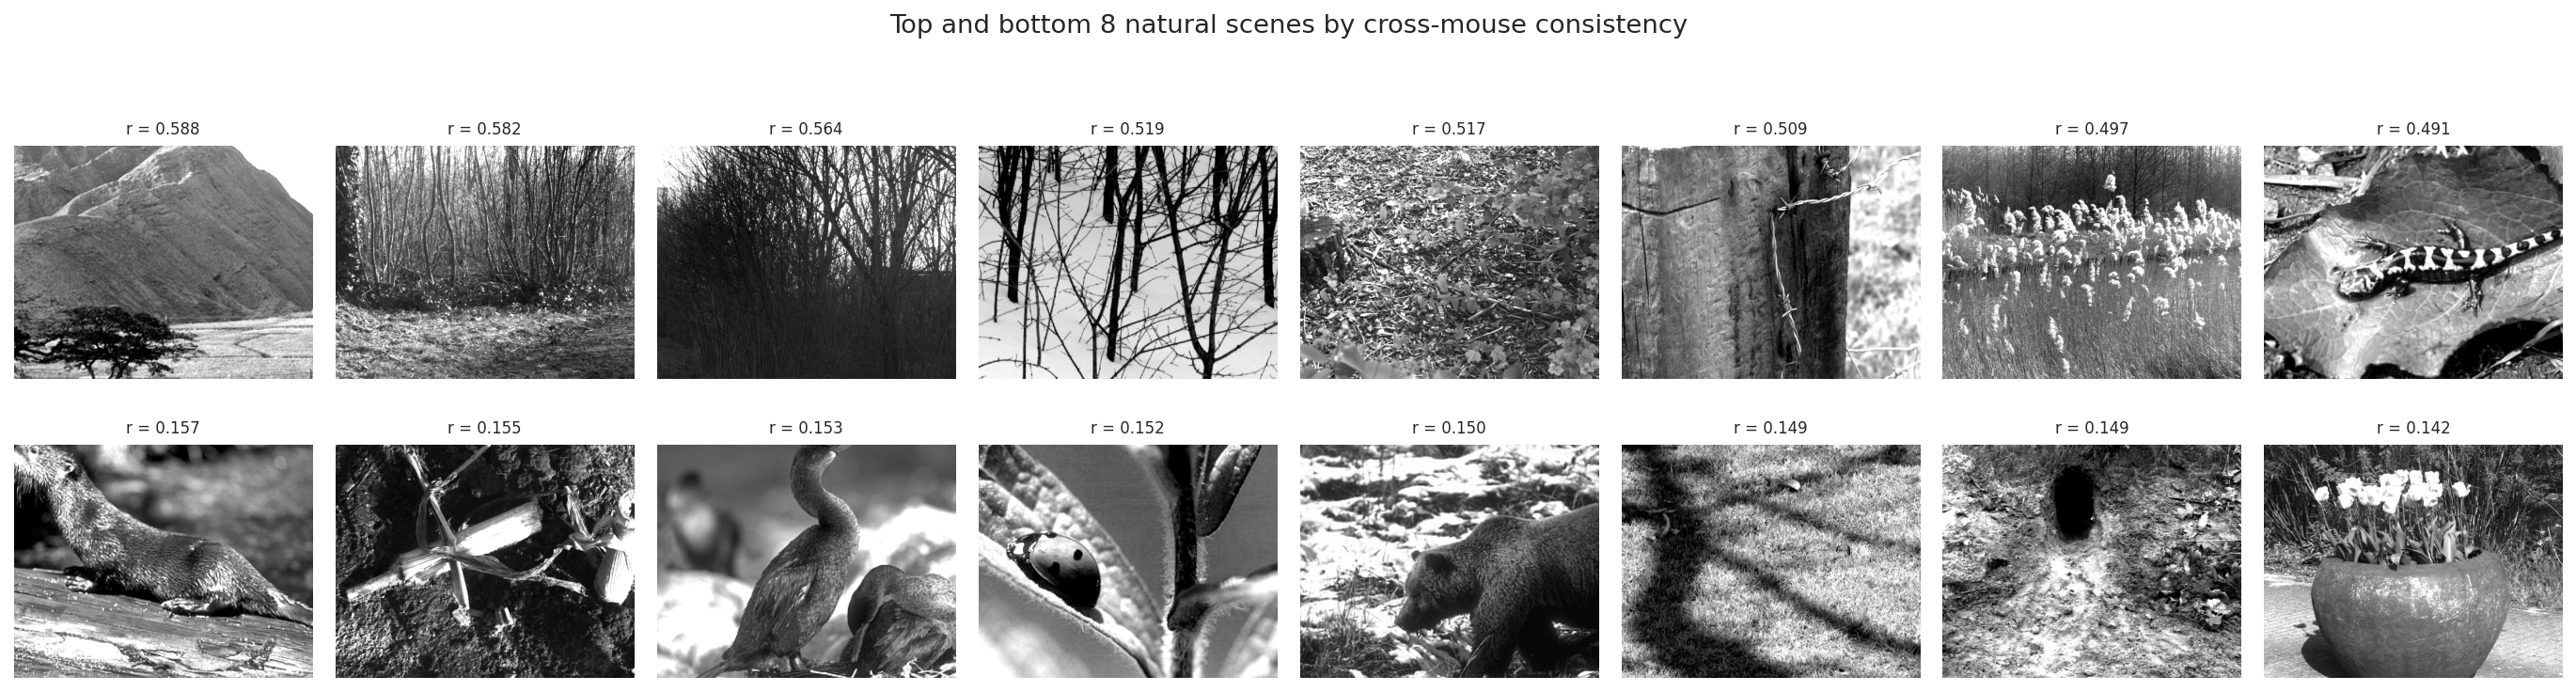

In [ ]:
# @title Most and least consistent images

fig, axes = plt.subplots(2, N_SHOW, figsize=(2.3 * N_SHOW, 5.2))
for i, img_id in enumerate(top_ids):
    axes[0, i].imshow(natural_scenes[img_id], cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f'r = {consistency[img_id]:.3f}', fontsize=8)
    axes[0, i].axis('off')
for i, img_id in enumerate(bot_ids):
    axes[1, i].imshow(natural_scenes[img_id], cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title(f'r = {consistency[img_id]:.3f}', fontsize=8)
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Most\nconsistent', fontsize=10, labelpad=6)
axes[1, 0].set_ylabel('Least\nconsistent', fontsize=10, labelpad=6)
fig.suptitle(f'Top and bottom {N_SHOW} natural scenes by cross-mouse consistency', y=1.01)
plt.tight_layout()
plt.savefig('fig_image_gallery.pdf', bbox_inches='tight')
plt.show()

**Methodological note.** Images are displayed in raw grayscale (0–255) without any normalisation, as presented to the animals. Consistency values shown in subtitles are the mean cross-mouse Spearman r from Part 2.1. This is a qualitative figure only — no statistical test is performed on image content.

## Part 2 — Image-Level Predictors of Consistency

Asks what distinguishes a highly-consistent image from a poorly-consistent one: response sparsity, magnitude, or learned visual complexity.


### 2.1 Response sparsity and magnitude

Test whether the variation in cross-mouse consistency across images is explained by how sparsely each image activates the population. Sparse responses are predicted to be more consistent because they engage a stereotyped, low-dimensional subspace.

In [ ]:
# @title Compute response sparsity and magnitude per image
def response_magnitude_sparsity(mouse_data, n_images=N_IMAGES):
    mags      = np.zeros((len(mouse_data), n_images))
    sparsities = np.zeros((len(mouse_data), n_images))
    for m, md in enumerate(mouse_data):
        X      = md['X']
        mags[m] = np.abs(X).mean(axis=1)
        thresh  = np.median(np.abs(X))
        sparsities[m] = (np.abs(X) < thresh).mean(axis=1)
    return mags.mean(axis=0), sparsities.mean(axis=0)

mean_magnitude, mean_sparsity = response_magnitude_sparsity(mouse_data_full)

r_sp,  p_sp  = spearmanr(consistency, mean_sparsity)
r_mag, p_mag = spearmanr(consistency, mean_magnitude)
print(f'Consistency vs. sparsity  : r = {r_sp:.3f},  p = {p_sp:.2e}')
print(f'Consistency vs. magnitude : r = {r_mag:.3f},  p = {p_mag:.2e}')

Consistency vs. sparsity  : r = -0.471,  p = 7.32e-08
Consistency vs. magnitude : r = 0.276,  p = 2.48e-03


**Methodological note.** Sparsity is defined as the fraction of units responding below the per-mouse median absolute z-score for a given image. This threshold-free definition is robust to session-level differences in overall firing rate. Both sparsity and magnitude are averaged across mice before correlating with consistency, so they represent population-level properties rather than single-session estimates. Spearman correlation is used for the same reason as elsewhere: robustness to outlier images.

No multiple comparisons correction is applied because sparsity and magnitude are not independent (they are negatively correlated by construction), so these are two perspectives on the same underlying dimension rather than independent tests.

### 2.2 CNN feature embeddings

Test whether image complexity, captured by ResNet50 layer activations, predicts consistency independently of sparsity.

In [ ]:
# @title CNN embeddings and partial correlation with sparsity
import torch
import torchvision.models as tv_models
import torchvision.transforms as T

CNN_LAYER = 'layer2'   # ResNet50 layer used for consistency prediction

device = 'cuda' if torch.cuda.is_available() else 'cpu'
preprocess = T.Compose([
    T.ToPILImage(), T.Resize(224), T.CenterCrop(224),
    T.Grayscale(num_output_channels=3), T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

model = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2).to(device).eval()
activations = {}
def hook(name):
    def fn(m, inp, out): activations[name] = out.detach()
    return fn
layers_to_hook = {'layer1': model.layer1, 'layer2': model.layer2,
                  'layer3': model.layer3, 'layer4': model.layer4}
handles = [l.register_forward_hook(hook(n)) for n, l in layers_to_hook.items()]
emb_by_layer = {n: [] for n in layers_to_hook}; emb_final = []
with torch.no_grad():
    for img in natural_scenes:
        img_u8 = ((img - img.min())/(img.max()-img.min()+1e-8)*255).astype(np.uint8)
        x = preprocess(img_u8).unsqueeze(0).to(device)
        out = model(x)
        emb_final.append(out.cpu().numpy().flatten())
        for n in layers_to_hook:
            emb_by_layer[n].append(activations[n].mean(dim=[2,3]).cpu().numpy().flatten())
for h in handles: h.remove()
layer_embeddings = {n: np.stack(v, 0) for n, v in emb_by_layer.items()}
layer_embeddings['final'] = np.stack(emb_final, 0)

# Ridge LOO for each layer — report LOO r directly (correct effect size)
layer_results = {}
for name, emb in layer_embeddings.items():
    Xs     = StandardScaler().fit_transform(emb)
    y_pred = cross_val_predict(RidgeCV(alphas=np.logspace(-2,6,30)), Xs,
                               consistency, cv=LeaveOneOut())
    r, p   = pearsonr(consistency, y_pred)
    layer_results[name] = {'r': r, 'r2': r**2, 'p': p, 'y_pred': y_pred}
    print(f'{name:>8s}: LOO r = {r:+.3f},  R² = {r**2:.3f},  p = {p:.2e}')

# Partial Spearman: CNN layer2 mean activation vs consistency,
# controlling for sparsity.
# IMPORTANT: use raw CNN features (mean activation per image) as the scalar
# proxy — NOT the LOO-predicted values, which would inflate the correlation
# by construction.
cnn_raw_proxy = layer_embeddings[CNN_LAYER].mean(axis=1)   # scalar per image

def partial_spearman(x, y, cov):
    def resid(a, b):
        ar = pd.Series(a).rank().values.astype(float)
        br = pd.Series(b).rank().values.astype(float)
        return ar - LinearRegression().fit(
            br.reshape(-1,1), ar).predict(br.reshape(-1,1))
    return spearmanr(resid(x, cov), resid(y, cov))

r_raw, p_raw = spearmanr(cnn_raw_proxy, consistency)
r_par, p_par = partial_spearman(cnn_raw_proxy, consistency, mean_sparsity)

print(f'\n{CNN_LAYER} mean activation vs consistency:')
print(f'  Raw Spearman r     : {r_raw:.3f},  p = {p_raw:.2e}')
print(f'  Partial (sparsity controlled): {r_par:.3f},  p = {p_par:.2e}')
print(f'  LOO r = {layer_results[CNN_LAYER]["r"]:.3f}')
print(f'  Partial r = {r_par:.3f} (p = {p_par:.2e})')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 108MB/s] 


  layer1: LOO r = -0.298,  R² = 0.089,  p = 1.03e-03
  layer2: LOO r = -0.496,  R² = 0.246,  p = 1.11e-08
  layer3: LOO r = -0.182,  R² = 0.033,  p = 4.89e-02
  layer4: LOO r = -0.243,  R² = 0.059,  p = 8.07e-03
   final: LOO r = -0.486,  R² = 0.236,  p = 2.48e-08

layer2 mean activation vs consistency:
  Raw Spearman r     : -0.017,  p = 8.56e-01
  Partial (sparsity controlled): 0.095,  p = 3.08e-01
  LOO r = -0.496
  Partial r = 0.095 (p = 3.08e-01)


**Methodological note.** ResNet50 pretrained on ImageNet (`IMAGENET1K_V2`) is used as a feature extractor. Global average pooling is applied to each convolutional block's output to reduce spatial dimensions to a fixed-length vector. Ridge regression with leave-one-out CV (118 images) is used rather than ordinary least squares because the feature dimension (256–2048) greatly exceeds the number of images, making OLS ill-posed. The partial Spearman correlation uses rank-residualisation: both x and y are rank-transformed, then the linear effect of the rank-transformed covariate is regressed out before computing the Spearman r of the residuals. This is the non-parametric equivalent of a partial correlation.

The LOO Pearson r values quantify how well each CNN
layer's full embedding predicts consistency in a high-dimensional ridge
regression — this is the correct effect size for the predictive claim.
The scalar partial correlation uses the mean activation of the best-performing layer (layer2) as a single-number proxy for CNN complexity, which allows partial correlation with sparsity. Critically, the raw CNN features (not LOO-predicted values) are used for the partial correlation; using LOO-predicted values would inflate the apparent effect size by
construction, since predictions are optimally correlated with the target.

## Part 3 — The Temporal Profile of Cross-Mouse Consensus

Resolves cross-mouse consistency at 10 ms resolution to ask whether agreement is uniform across the visual response or concentrated in a transient window, and tests this with two independent corroborating measures (image-rank stability, second-order RSA).

### 3.1 Two-window comparison: early vs. late

A coarse two-window split, used here only to motivate the finer-grained analysis in 3.2.

In [ ]:
# @title Early vs. late window consistency
EARLY_WINDOW = (0.000, 0.075)   # seconds
LATE_WINDOW  = (0.075, 0.250)   # seconds

window_results = {}
for label, win in [('early', EARLY_WINDOW), ('late', LATE_WINDOW)]:
    mouse_data_win = []
    for sid in selected_session_ids:
        result = load_session_response_matrix(
            sid, cache, area='VISp', window=win, verbose=False
        )
        if result is not None:
            mouse_data_win.append(result)
        gc.collect()
    sims_w = compute_similarity_matrices(mouse_data_win)
    c_w, _, _ = per_image_consistency(sims_w)
    window_results[label] = c_w
    print(f'{label:5s} ({int(win[0]*1000)}–{int(win[1]*1000)} ms): '
          f'mean consistency = {c_w.mean():.3f}')

stat_wil, p_wil = wilcoxon(window_results['early'], window_results['late'])
print(f'\nWilcoxon signed-rank (paired by image): '
      f'stat = {stat_wil:.1f},  p = {p_wil:.2e}')

early (0–75 ms): mean consistency = 0.084
late  (75–250 ms): mean consistency = 0.320

Wilcoxon signed-rank (paired by image): stat = 0.0,  p = 4.21e-21


**Methodological note.** The split at 75 ms separates the early feedforward epoch (dominated by thalamic input arriving in V1 at ~40–70 ms in mice) from a later epoch that includes recurrent and feedback contributions. The boundary is a principled neuroscientific choice, not optimised to maximise the difference. A Wilcoxon signed-rank test is used rather than a paired t-test because the per-image consistency values are bounded (Spearman r ∈ [−1, 1]) and their distribution is not guaranteed to be normal.

The Spearman r between early and late image rankings answers a different question from the Wilcoxon test: whether the same images are consistently represented in both windows (high r) or whether the identity of which images are shared changes across the epoch (low r). Both statistics are reported because they are complementary.

### 3.2 Sliding-window temporal profile

Resolve the full time course of cross-mouse consensus with 25 ms windows stepped in 10 ms increments from −50 ms to +370 ms relative to stimulus onset. A pre-stimulus baseline at ≈ 0 validates the measure; the onset, peak, and decay timing of cross-mouse agreement are the primary outcomes.

In [ ]:
# @title Sliding-window consistency
WINDOW_WIDTH_MS = 25    # ms
WINDOW_STEP_MS  = 10    # ms
SLIDE_START_MS  = -50   # ms
SLIDE_END_MS    = 375   # ms

window_centers_ms = list(range(SLIDE_START_MS, SLIDE_END_MS, WINDOW_STEP_MS))
window_matrices   = {t: [] for t in window_centers_ms}

for sid in selected_session_ids:
    unit_ids = get_unit_ids_for_session(cache, sid, area='VISp')
    if len(unit_ids) < MIN_UNITS:
        continue
    session  = cache.get_session_data(sid)
    stim     = session.stimulus_presentations.copy()
    stim['frame'] = pd.to_numeric(stim['frame'], errors='coerce')
    ns       = stim[(stim.stimulus_name == 'natural_scenes') & (stim['frame'] >= 0)].copy()
    image_ids = sorted(ns.frame.unique())
    if len(image_ids) != N_IMAGES:
        del session; gc.collect(); continue
    nwb_path    = get_nwb_path(sid)
    unit_id_set = set(unit_ids)
    unit_spike_times = {}
    with h5py.File(nwb_path, 'r') as f:
        nwb_ids  = f['units/id'][:]
        spk_flat = f['units/spike_times'][:]
        spk_idx  = f['units/spike_times_index'][:]
        for i, uid in enumerate(nwb_ids):
            if uid not in unit_id_set:
                continue
            s = 0 if i == 0 else int(spk_idx[i-1])
            e = int(spk_idx[i])
            unit_spike_times[uid] = spk_flat[s:e]
    starts = ns['start_time'].values
    frames = ns['frame'].values.astype(int)
    del session; gc.collect()
    for t_ms in window_centers_ms:
        t0 = (t_ms - WINDOW_WIDTH_MS / 2) / 1000.0
        t1 = (t_ms + WINDOW_WIDTH_MS / 2) / 1000.0
        trial_starts = starts + t0
        trial_ends   = starts + t1
        counts = np.zeros((len(starts), len(unit_ids)), dtype=np.float32)
        for j, uid in enumerate(unit_ids):
            spikes = unit_spike_times.get(uid, np.array([]))
            if len(spikes) == 0:
                continue
            idx   = np.searchsorted(trial_starts, spikes, side='right') - 1
            valid = (idx >= 0) & (idx < len(starts))
            idx   = idx[valid];  sp = spikes[valid]
            in_w  = sp < trial_ends[idx]
            np.add.at(counts[:, j], idx[in_w], 1)
        X = np.zeros((N_IMAGES, len(unit_ids)), dtype=np.float32)
        for i, img in enumerate(image_ids):
            X[i] = counts[frames == img].mean(axis=0)
        X = (X - X.mean(0)) / (X.std(0) + 1e-8)
        window_matrices[t_ms].append({'session_id': sid, 'X': X,
                                      'image_ids': np.array(image_ids)})
    del unit_spike_times, counts; gc.collect()

sliding_per_image = {}
for t_ms in window_centers_ms:
    mdata = window_matrices[t_ms]
    if len(mdata) < 5:
        continue
    sims    = compute_similarity_matrices(mdata)
    c, _, _ = per_image_consistency(sims, n_images=N_IMAGES)
    sliding_per_image[t_ms] = c
    print(f't = {t_ms:+4d} ms : mean consistency = {c.mean():.3f}  '
          f'(n_mice = {len(mdata)})')

del window_matrices; gc.collect()

times_ms = sorted(sliding_per_image.keys())
mean_c   = np.array([sliding_per_image[t].mean() for t in times_ms])
peak_t   = times_ms[np.argmax(mean_c)]
peak_c   = mean_c.max()
pre_mask = np.array(times_ms) < 0
baseline = mean_c[pre_mask].mean()
onset_t  = next((t for t, c in zip(times_ms, mean_c)
                 if t >= 0 and c > max(2 * baseline, 0.05)), None)
print(f'\nPeak: {peak_c:.3f} at t = {peak_t} ms')
print(f'Onset (>0.05): {onset_t} ms')
print(f'Pre-stimulus baseline: {baseline:.4f}')

t =  -50 ms : mean consistency = -0.000  (n_mice = 32)
t =  -40 ms : mean consistency = 0.000  (n_mice = 32)
t =  -30 ms : mean consistency = -0.000  (n_mice = 32)
t =  -20 ms : mean consistency = 0.000  (n_mice = 32)
t =  -10 ms : mean consistency = -0.000  (n_mice = 32)
t =   +0 ms : mean consistency = -0.000  (n_mice = 32)
t =  +10 ms : mean consistency = 0.001  (n_mice = 32)
t =  +20 ms : mean consistency = -0.000  (n_mice = 32)
t =  +30 ms : mean consistency = 0.002  (n_mice = 32)
t =  +40 ms : mean consistency = 0.034  (n_mice = 32)
t =  +50 ms : mean consistency = 0.091  (n_mice = 32)
t =  +60 ms : mean consistency = 0.148  (n_mice = 32)
t =  +70 ms : mean consistency = 0.198  (n_mice = 32)
t =  +80 ms : mean consistency = 0.253  (n_mice = 32)
t =  +90 ms : mean consistency = 0.289  (n_mice = 32)
t = +100 ms : mean consistency = 0.306  (n_mice = 32)
t = +110 ms : mean consistency = 0.306  (n_mice = 32)
t = +120 ms : mean consistency = 0.299  (n_mice = 32)
t = +130 ms : mean cons

**Methodological note.** The single-pass approach (load each session's NWB file once, count spikes into all windows simultaneously) is used to keep total runtime tractable; it is mathematically equivalent to running separate analyses per window. Window width (25 ms) was chosen to provide sufficient spike count reliability in a 25 ms epoch at typical V1 firing rates (~5–20 Hz), while step size (10 ms) provides temporal resolution finer than the window width (overlapping windows). The onset threshold (first window where mean consistency > 0.05 or > 2× pre-stimulus baseline) is a conservative operational definition; the exact threshold does not materially affect the onset estimate given the steepness of the rise.

The pre-stimulus baseline shading covers −50 ms to 0 ms; the near-zero consistency in this region confirms that the post-stimulus rise is stimulus-driven and not an artefact of slow drift or correlated spontaneous activity across animals. The stimulus offset line at 250 ms marks the end of the 250 ms natural-scene presentation; any consistency after this point reflects sustained or after-discharge activity.

### 3.3 Two-component decomposition: transient peak vs. sustained floor

The temporal profile shows a transient peak (100 ms) followed by a decay to a sustained non-zero floor (0.18 from 240 ms onward). Fit a Gaussian-plus-offset model to decompose these two components and test whether they are statistically distinct from one another and from baseline.

In [ ]:
# @title Two-component decomposition: Gaussian + sustained offset
from scipy.optimize import curve_fit

SUSTAINED_WINDOW_START_MS = 220   # ms — start of sustained epoch for floor estimate
SUSTAINED_WINDOW_END_MS   = 250   # ms

times_arr = np.array(times_ms, dtype=float)
post_mask = times_arr >= 0

# Estimate sustained floor from late post-stimulus epoch
sus_mask = (times_arr >= SUSTAINED_WINDOW_START_MS) & (times_arr <= SUSTAINED_WINDOW_END_MS)
sustained_floor    = mean_c[sus_mask].mean()
sustained_floor_sd = mean_c[sus_mask].std()

# Fit Gaussian + offset to post-stimulus curve
def gauss_plus_offset(t, amp, mu, sigma, offset):
    return amp * np.exp(-0.5 * ((t - mu) / sigma) ** 2) + offset

p0     = [peak_c - sustained_floor, peak_t, 40.0, sustained_floor]
bounds = ([0, 50, 10, 0], [1, 200, 150, 0.5])
try:
    popt, pcov = curve_fit(
        gauss_plus_offset, times_arr[post_mask], mean_c[post_mask],
        p0=p0, bounds=bounds, maxfev=10000
    )
    perr = np.sqrt(np.diag(pcov))
    amp_fit, mu_fit, sigma_fit, offset_fit = popt
    fit_success = True
except Exception as e:
    print(f'Fit failed: {e}')
    fit_success = False

# Statistical test: is sustained floor > 0?
from scipy.stats import ttest_1samp
sus_vals = mean_c[sus_mask]
t_sus, p_sus = ttest_1samp(sus_vals, 0)

print(f'Sustained floor ({SUSTAINED_WINDOW_START_MS}–{SUSTAINED_WINDOW_END_MS} ms): '
      f'mean = {sustained_floor:.3f} ± {sustained_floor_sd:.3f}')
print(f'One-sample t-test vs 0: t = {t_sus:.2f},  p = {p_sus:.2e}')
if fit_success:
    print(f'\nGaussian fit (post-stimulus):')
    print(f'  Transient amplitude : {amp_fit:.3f} ± {perr[0]:.3f}')
    print(f'  Peak centre (mu)    : {mu_fit:.1f} ± {perr[1]:.1f} ms')
    print(f'  Width (sigma)       : {sigma_fit:.1f} ± {perr[2]:.1f} ms')
    print(f'  Sustained offset    : {offset_fit:.3f} ± {perr[3]:.3f}')

Sustained floor (220–250 ms): mean = 0.182 ± 0.003
One-sample t-test vs 0: t = 94.75,  p = 2.59e-06

Gaussian fit (post-stimulus):
  Transient amplitude : 0.162 ± 0.035
  Peak centre (mu)    : 124.7 ± 8.1 ms
  Width (sigma)       : 34.2 ± 9.2 ms
  Sustained offset    : 0.149 ± 0.015


**Methodological note.** The Gaussian-plus-offset model is a phenomenological description, not a mechanistic model. It is the minimal parametric form consistent with the observed shape (single transient peak plus a sustained plateau). The fit is constrained to the post-stimulus epoch (t ≥ 0) because the pre-stimulus data is uninformative about the shape of the response and would artificially drag the offset downward. The sustained floor is also estimated non-parametrically from the mean in the 220–250 ms window; this estimate is compared to the model's `offset` parameter as a consistency check. The one-sample t-test tests whether the sustained floor differs from zero, treating the per-window mean consistency values in the sustained epoch as observations; this is a conservative test because successive 10 ms windows are not independent (overlapping windows), so the effective n is lower than the number of windows.

The sustained floor is estimated from
220–250 ms specifically to avoid contamination from the neural response
to the next stimulus. In the brain_observatory_1.1 protocol, natural
scenes are presented back-to-back with no inter-stimulus interval; the
next image's response arrives in V1 at approximately 290–300 ms (onset
~250 ms + ~40–50 ms response latency). Any window extending beyond
250 ms therefore risks capturing the rising edge of the next image's
response rather than the sustained floor of the current image. All
sustained floor estimates throughout the paper are restricted to
220–250 ms for this reason.

### 3.4 — Image-ranking stability across the response epoch

Test whether the same images are most consistently represented throughout the response, or whether the identity of which images drive shared structure shifts around the 100 ms peak. A high rank correlation between early and peak windows would indicate stable image ordering; a low correlation would indicate that the transient and sustained components represent different images.

In [ ]:
# @title Image-ranking correlation across epochs
EPOCH_TARGETS_MS = {
    'Pre (-25 ms)':        -25,
    'Early FF (25 ms)':     25,
    'Ramp (50 ms)':         50,
    'Peak (100 ms)':       100,
    'Decay (175 ms)':      175,
    'Sustained (250 ms)':  250,
}

avail = sorted(sliding_per_image.keys())
def snap(t): return min(avail, key=lambda x: abs(x - t))

epoch_labels = list(EPOCH_TARGETS_MS.keys())
epoch_times  = [snap(v) for v in EPOCH_TARGETS_MS.values()]
n_epochs     = len(epoch_labels)

rank_corr = np.full((n_epochs, n_epochs), np.nan)
rank_p    = np.full((n_epochs, n_epochs), np.nan)
for i, t1 in enumerate(epoch_times):
    for j, t2 in enumerate(epoch_times):
        r, p = spearmanr(sliding_per_image[t1], sliding_per_image[t2])
        rank_corr[i, j] = r
        rank_p[i, j]    = p

# Rolling correlation vs. peak window
peak_key     = snap(100)
r_vs_peak    = [spearmanr(sliding_per_image[t], sliding_per_image[peak_key])[0]
                for t in avail]
p_vs_peak    = [spearmanr(sliding_per_image[t], sliding_per_image[peak_key])[1]
                for t in avail]

print('Rank-correlation matrix (Spearman r):')
df_rc = pd.DataFrame(rank_corr, index=[f'{t}ms' for t in epoch_times],
                     columns=[f'{t}ms' for t in epoch_times])
print(df_rc.round(3).to_string())

Rank-correlation matrix (Spearman r):
       -30ms   20ms   50ms  100ms  170ms  250ms
-30ms  1.000  0.002 -0.057  0.100 -0.028 -0.034
20ms   0.002  1.000 -0.016 -0.080 -0.046 -0.087
50ms  -0.057 -0.016  1.000  0.196  0.153  0.238
100ms  0.100 -0.080  0.196  1.000  0.614  0.649
170ms -0.028 -0.046  0.153  0.614  1.000  0.886
250ms -0.034 -0.087  0.238  0.649  0.886  1.000


**Methodological note.** The rank correlation matrix measures whether the ordering of images by cross-mouse consistency is stable across epochs. Spearman r is used (rather than Pearson) because we care about rank agreement, not linear proportionality. The rolling correlation vs. the peak window provides a temporal readout of how quickly the image ordering diverges from the peak. Epochs are snapped to the nearest computed window centre to avoid interpolation.

We're using uncorrected p-values for illustration; multiple comparisons across time points are not corrected because these are 43 correlated, overlapping windows, not independent tests. The reference window (peak, 100 ms) is chosen based on the empirical peak identified in Part 3.2, not pre-registered.

### 3.5 — Second-order RSA: Cross-Mouse Consistency of Temporal Profiles

Tests whether mice agree not just on which images are consistently represented, but on how that consistency evolves over time per image.

In [ ]:
# @title Second-order RSA using representational similarity profiles
# Computes per-mouse, per-image similarity PROFILES across 5 key time windows,
# then correlates those profiles between mouse pairs.

from itertools import combinations

# Five key windows — chosen to span the full temporal profile
# without storing the full 38-window stack
SO_WINDOWS_MS = {
    'pre':       -25,   # pre-stimulus baseline
    'early':      50,   # feedforward onset
    'peak':      100,   # consistency peak
    'decay':     175,   # post-peak decay
    'sustained': 250,   # sustained floor (last clean window before next stimulus)
}

# Snap each target to nearest available window
avail_t = sorted(sliding_per_image.keys())
so_windows_snapped = {
    label: min(avail_t, key=lambda t: abs(t - target))
    for label, target in SO_WINDOWS_MS.items()
}
so_window_list = list(so_windows_snapped.values())   # ordered list of t_ms values
n_so_windows   = len(so_window_list)

print('Second-order RSA windows:')
for label, t_ms in so_windows_snapped.items():
    print(f'  {label:>10s}: {t_ms:+4d} ms')

# Memory estimate
# Per mouse: N_IMAGES × (N_IMAGES-1) × n_windows × 4 bytes
# = 118 × 117 × 5 × 4 = 276,120 bytes ≈ 0.26 MB per mouse
# Total: 32 × 0.26 MB ≈ 8.4 MB — very manageable
mem_mb = len(selected_session_ids) * N_IMAGES * (N_IMAGES-1) * n_so_windows * 4 / 1e6
print(f'\nEstimated memory for similarity profiles: {mem_mb:.1f} MB')

# For each mouse and each window, compute the full cosine similarity matrix,
# then store only the off-diagonal rows (the similarity profile of each image
# to all other images). Shape per mouse: (N_IMAGES, N_IMAGES-1, n_windows)

print('\nComputing per-mouse representational similarity profiles...')

# Store as list of (N_IMAGES, N_IMAGES-1, n_windows) arrays
mouse_sim_profiles = []   # one entry per valid session
mouse_sim_sids     = []   # corresponding session IDs

off_diag_mask = ~np.eye(N_IMAGES, dtype=bool)   # True for off-diagonal

for sid in selected_session_ids:
    unit_ids = get_unit_ids_for_session(cache, sid, area='VISp')
    if len(unit_ids) < MIN_UNITS:
        continue
    session = cache.get_session_data(sid)
    stim    = session.stimulus_presentations.copy()
    stim['frame'] = pd.to_numeric(stim['frame'], errors='coerce')
    ns      = stim[(stim.stimulus_name == 'natural_scenes') &
                   (stim['frame'] >= 0)].copy()
    image_ids = sorted(ns.frame.unique())
    if len(image_ids) != N_IMAGES:
        del session; gc.collect(); continue
    nwb_path    = get_nwb_path(sid)
    unit_id_set = set(unit_ids)
    unit_spike_times = {}
    with h5py.File(nwb_path, 'r') as f:
        nwb_ids  = f['units/id'][:]
        spk_flat = f['units/spike_times'][:]
        spk_idx  = f['units/spike_times_index'][:]
        for i, uid in enumerate(nwb_ids):
            if uid not in unit_id_set:
                continue
            s = 0 if i == 0 else int(spk_idx[i - 1])
            e = int(spk_idx[i])
            unit_spike_times[uid] = spk_flat[s:e]
    starts    = ns['start_time'].values
    frames    = ns['frame'].values.astype(int)
    del session; gc.collect()

    # (N_IMAGES, N_IMAGES-1, n_windows) — similarity profile per image per window
    sim_profile = np.zeros((N_IMAGES, N_IMAGES - 1, n_so_windows), dtype=np.float32)

    for w_idx, t_ms in enumerate(so_window_list):
        t0 = (t_ms - WINDOW_WIDTH_MS / 2) / 1000.0
        t1 = (t_ms + WINDOW_WIDTH_MS / 2) / 1000.0
        trial_starts = starts + t0
        trial_ends   = starts + t1
        counts = np.zeros((len(starts), len(unit_ids)), dtype=np.float32)
        for j, uid in enumerate(unit_ids):
            spikes = unit_spike_times.get(uid, np.array([]))
            if len(spikes) == 0:
                continue
            idx   = np.searchsorted(trial_starts, spikes, side='right') - 1
            valid = (idx >= 0) & (idx < len(starts))
            idx   = idx[valid]; sp = spikes[valid]
            in_w  = sp < trial_ends[idx]
            np.add.at(counts[:, j], idx[in_w], 1)

        X = np.zeros((N_IMAGES, len(unit_ids)), dtype=np.float32)
        for i, img in enumerate(image_ids):
            X[i] = counts[frames == img].mean(axis=0)
        X = (X - X.mean(0)) / (X.std(0) + 1e-8)

        # Cosine similarity matrix
        norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
        sim  = norm @ norm.T   # (N_IMAGES, N_IMAGES)

        # Store off-diagonal rows: each image's similarity profile to all others
        sim_profile[:, :, w_idx] = sim[off_diag_mask].reshape(N_IMAGES, N_IMAGES - 1)
        del counts

    mouse_sim_profiles.append(sim_profile)
    mouse_sim_sids.append(sid)
    del unit_spike_times; gc.collect()

n_mice_so = len(mouse_sim_profiles)
print(f'Profiles computed: {n_mice_so} mice × {N_IMAGES} images × '
      f'{N_IMAGES-1} neighbours × {n_so_windows} windows')

Second-order RSA windows:
         pre:  -30 ms
       early:  +50 ms
        peak: +100 ms
       decay: +170 ms
   sustained: +250 ms

Estimated memory for similarity profiles: 8.8 MB

Computing per-mouse representational similarity profiles...
Profiles computed: 32 mice × 118 images × 117 neighbours × 5 windows


In [ ]:
# @title Compute second-order RSA (proper representational version)

# For each image, for each mouse pair, compute the Spearman correlation
# between their flattened similarity profiles across windows.
# Each mouse's profile for image i is a vector of length (N_IMAGES-1) × n_windows
# = 117 × 5 = 585 values, capturing how similar image i is to each other image
# at each time window.
#
# High second-order r for image i means: the pattern of which images are similar
# to i, and how that pattern changes over time, is consistent across mice.
# This is a genuine representational dynamics measure.

pairs_so = list(combinations(range(n_mice_so), 2))
n_pairs  = len(pairs_so)

second_order_r_rep = np.zeros(N_IMAGES, dtype=np.float32)
second_order_r_rep_by_window = np.zeros((N_IMAGES, n_so_windows), dtype=np.float32)

print(f'Computing second-order RSA across {n_pairs} mouse pairs × {N_IMAGES} images...')

for img_i in range(N_IMAGES):
    rs_flat    = []   # correlating flattened (N_IMAGES-1 × n_windows) profiles
    rs_per_win = [[] for _ in range(n_so_windows)]

    for a, b in pairs_so:
        # Profile for image i: (N_IMAGES-1, n_windows) for each mouse
        prof_a = mouse_sim_profiles[a][img_i]   # (N_IMAGES-1, n_windows)
        prof_b = mouse_sim_profiles[b][img_i]

        # Flattened: correlate full spatio-temporal similarity profile
        flat_a = prof_a.flatten()
        flat_b = prof_b.flatten()
        if flat_a.std() < 1e-6 or flat_b.std() < 1e-6:
            continue
        r, _ = spearmanr(flat_a, flat_b)
        rs_flat.append(r)

        # Per-window: correlate similarity profiles at each time point separately
        for w in range(n_so_windows):
            wa = prof_a[:, w]
            wb = prof_b[:, w]
            if wa.std() < 1e-6 or wb.std() < 1e-6:
                continue
            r_w, _ = spearmanr(wa, wb)
            rs_per_win[w].append(r_w)

    second_order_r_rep[img_i] = np.mean(rs_flat) if rs_flat else np.nan
    for w in range(n_so_windows):
        second_order_r_rep_by_window[img_i, w] = (
            np.mean(rs_per_win[w]) if rs_per_win[w] else np.nan
        )

print(f'\nSecond-order RSA (representational similarity profiles):')
print(f'  Mean across images : {np.nanmean(second_order_r_rep):.3f}')
print(f'  Range              : [{np.nanmin(second_order_r_rep):.3f}, '
      f'{np.nanmax(second_order_r_rep):.3f}]')
print(f'  Images with r > 0  : {(second_order_r_rep > 0).sum()} / {N_IMAGES}')

# Per-window breakdown
print(f'\nPer-window mean second-order r:')
for w, (label, t_ms) in enumerate(so_windows_snapped.items()):
    mean_w = np.nanmean(second_order_r_rep_by_window[:, w])
    print(f'  {label:>10s} ({t_ms:+4d} ms): {mean_w:.3f}')

# Correlations with first-order consistency and other image properties
r_so_fo, p_so_fo = spearmanr(second_order_r_rep, consistency, nan_policy='omit')
r_so_sp, p_so_sp = spearmanr(second_order_r_rep, mean_sparsity, nan_policy='omit')

print(f'\nCorrelations with image properties:')
print(f'  First-order consistency : r = {r_so_fo:.3f},  p = {p_so_fo:.2e}')
print(f'  Sparsity                : r = {r_so_sp:.3f},  p = {p_so_sp:.2e}')
print(f'  Mean r = {np.nanmean(second_order_r_rep):.3f}')
print(f'  r(second-order, first-order) = {r_so_fo:.3f}')

Computing second-order RSA across 496 mouse pairs × 118 images...

Second-order RSA (representational similarity profiles):
  Mean across images : 0.187
  Range              : [0.071, 0.412]
  Images with r > 0  : 118 / 118

Per-window mean second-order r:
         pre ( -30 ms): -0.000
       early ( +50 ms): 0.091
        peak (+100 ms): 0.306
       decay (+170 ms): 0.226
   sustained (+250 ms): 0.179

Correlations with image properties:
  First-order consistency : r = 0.949,  p = 5.00e-60
  Sparsity                : r = -0.512,  p = 3.08e-09
  Mean r = 0.187
  r(second-order, first-order) = 0.949


## Part 4 — Representational Geometry: Dimensionality of the Shared Attractor

Tests the geometric correlate of the temporal peak: whether the consistency maximum coincides with a collapse in the dimensionality of the shared representation, and characterizes what that compressed space looks like.


In [ ]:
# =============================================================================
# Part 4 — Intrinsic Dimensionality of the Shared Representational Space Over Time
# =============================================================================
# Tests whether the transient peak coincides with high-dimensional representations
# that collapse into a lower-dimensional sustained state — the core prediction of
# the recurrent/feedback hypothesis.
# Requires: sliding_per_image, times_ms, mean_c, peak_t, N_IMAGES
# =============================================================================


# @title 4.1 — Participation ratio over time
# Computes PR on the fly per session/window — never accumulates full matrix stack

def participation_ratio(matrix):
    eigvals = np.linalg.eigvalsh(matrix)
    eigvals = np.maximum(eigvals, 0)
    total   = eigvals.sum()
    if total == 0:
        return np.nan
    return total**2 / (eigvals**2).sum()

def similarity_matrix_from_X(X):
    norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
    return norm @ norm.T

# Subsample time windows to every other step to halve compute
# (still 20 ms resolution, plenty for a smooth curve)
PR_TIME_POINTS = sorted(sliding_per_image.keys())[::2]

# Running accumulators: sum and sum-of-squares for PR of avg sim matrix,
# plus per-mouse PR mean/M2 for Welford online mean+variance.
# We never store more than one session's matrices at a time.
pr_sum_sim   = {t: np.zeros((N_IMAGES, N_IMAGES), dtype=np.float64)
                for t in PR_TIME_POINTS}   # running sum of sim matrices
pr_n_mice    = {t: 0   for t in PR_TIME_POINTS}   # count of mice contributing
pr_mouse_sum = {t: 0.0 for t in PR_TIME_POINTS}   # for per-mouse PR mean
pr_mouse_ss  = {t: 0.0 for t in PR_TIME_POINTS}   # sum of squares for SEM

print('Computing PR — single-pass, on-the-fly accumulation...')
for sid in selected_session_ids:
    unit_ids = get_unit_ids_for_session(cache, sid, area='VISp')
    if len(unit_ids) < MIN_UNITS:
        continue
    session = cache.get_session_data(sid)
    stim    = session.stimulus_presentations.copy()
    stim['frame'] = pd.to_numeric(stim['frame'], errors='coerce')
    ns      = stim[(stim.stimulus_name == 'natural_scenes') & (stim['frame'] >= 0)].copy()
    image_ids = sorted(ns.frame.unique())
    if len(image_ids) != N_IMAGES:
        del session; gc.collect(); continue
    nwb_path    = get_nwb_path(sid)
    unit_id_set = set(unit_ids)
    unit_spike_times = {}
    with h5py.File(nwb_path, 'r') as f:
        nwb_ids  = f['units/id'][:]
        spk_flat = f['units/spike_times'][:]
        spk_idx  = f['units/spike_times_index'][:]
        for i, uid in enumerate(nwb_ids):
            if uid not in unit_id_set:
                continue
            s = 0 if i == 0 else int(spk_idx[i - 1])
            e = int(spk_idx[i])
            unit_spike_times[uid] = spk_flat[s:e]
    starts = ns['start_time'].values
    frames = ns['frame'].values.astype(int)
    del session; gc.collect()

    for t_ms in PR_TIME_POINTS:
        t0 = (t_ms - WINDOW_WIDTH_MS / 2) / 1000.0
        t1 = (t_ms + WINDOW_WIDTH_MS / 2) / 1000.0
        trial_starts = starts + t0
        trial_ends   = starts + t1
        counts = np.zeros((len(starts), len(unit_ids)), dtype=np.float32)
        for j, uid in enumerate(unit_ids):
            spikes = unit_spike_times.get(uid, np.array([]))
            if len(spikes) == 0:
                continue
            idx   = np.searchsorted(trial_starts, spikes, side='right') - 1
            valid = (idx >= 0) & (idx < len(starts))
            idx   = idx[valid]; sp = spikes[valid]
            in_w  = sp < trial_ends[idx]
            np.add.at(counts[:, j], idx[in_w], 1)
        X = np.zeros((N_IMAGES, len(unit_ids)), dtype=np.float32)
        for i, img in enumerate(image_ids):
            X[i] = counts[frames == img].mean(axis=0)
        X = (X - X.mean(0)) / (X.std(0) + 1e-8)

        # Compute this mouse's similarity matrix and immediately accumulate
        sim = similarity_matrix_from_X(X).astype(np.float64)
        pr_sum_sim[t_ms]   += sim          # accumulate for avg sim matrix
        pr_n_mice[t_ms]    += 1
        pr_this             = participation_ratio(sim)
        pr_mouse_sum[t_ms] += pr_this      # for per-mouse mean PR
        pr_mouse_ss[t_ms]  += pr_this**2
        del sim, X, counts                 # discard immediately

    del unit_spike_times; gc.collect()

# Finalise: compute PR of the average similarity matrix
pr_results = {}
for t_ms in PR_TIME_POINTS:
    n = pr_n_mice[t_ms]
    if n < 5:
        continue
    avg_sim     = pr_sum_sim[t_ms] / n
    pr_avg      = participation_ratio(avg_sim)
    mouse_mean  = pr_mouse_sum[t_ms] / n
    mouse_var   = max(pr_mouse_ss[t_ms] / n - mouse_mean**2, 0)
    mouse_sem   = np.sqrt(mouse_var / n)
    pr_results[t_ms] = {
        'pr_avg':        pr_avg,
        'pr_mouse_mean': mouse_mean,
        'pr_mouse_sem':  mouse_sem,
    }
    print(f't = {t_ms:+4d} ms : PR(avg sim) = {pr_avg:.2f},  '
          f'PR(per-mouse) = {mouse_mean:.2f} ± {mouse_sem:.2f}')

del pr_sum_sim; gc.collect()

times_pr  = sorted(pr_results.keys())
pr_avg_ts = np.array([pr_results[t]['pr_avg']        for t in times_pr])
pr_pmm_ts = np.array([pr_results[t]['pr_mouse_mean'] for t in times_pr])
pr_sem_ts = np.array([pr_results[t]['pr_mouse_sem']  for t in times_pr])

pre_pr    = np.mean([pr_results[t]['pr_avg'] for t in times_pr if t < 0])
sus_t_pr  = min(times_pr, key=lambda t: abs(t - 250))
print(f'\nPR pre-stimulus baseline : {pre_pr:.2f}')
print(f'PR at peak ({peak_t} ms)      : {pr_results[min(times_pr, key=lambda t: abs(t-peak_t))]["pr_avg"]:.2f}')
print(f'PR at sustained (250 ms) : {pr_results[sus_t_pr]["pr_avg"]:.2f}')

Computing PR — single-pass, on-the-fly accumulation...
t =  -50 ms : PR(avg sim) = 108.10,  PR(per-mouse) = 35.74 ± 1.77
t =  -30 ms : PR(avg sim) = 107.95,  PR(per-mouse) = 35.54 ± 1.78
t =  -10 ms : PR(avg sim) = 108.02,  PR(per-mouse) = 35.50 ± 1.78
t =  +10 ms : PR(avg sim) = 107.67,  PR(per-mouse) = 35.30 ± 1.74
t =  +30 ms : PR(avg sim) = 107.65,  PR(per-mouse) = 35.44 ± 1.73
t =  +50 ms : PR(avg sim) = 83.85,  PR(per-mouse) = 30.90 ± 1.45
t =  +70 ms : PR(avg sim) = 52.93,  PR(per-mouse) = 21.49 ± 0.98
t =  +90 ms : PR(avg sim) = 31.63,  PR(per-mouse) = 15.29 ± 0.78
t = +110 ms : PR(avg sim) = 31.22,  PR(per-mouse) = 15.48 ± 0.86
t = +130 ms : PR(avg sim) = 38.02,  PR(per-mouse) = 18.13 ± 0.97
t = +150 ms : PR(avg sim) = 46.59,  PR(per-mouse) = 21.08 ± 1.03
t = +170 ms : PR(avg sim) = 52.43,  PR(per-mouse) = 22.57 ± 1.03
t = +190 ms : PR(avg sim) = 55.92,  PR(per-mouse) = 23.39 ± 1.11
t = +210 ms : PR(avg sim) = 58.81,  PR(per-mouse) = 24.11 ± 1.17
t = +230 ms : PR(avg sim) = 61

In [ ]:
# @title 4.2 — Eigenvector characterization of the peak attractor

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict

N_EIGVECS = 8  # number of top eigenvectors to examine

# Recompute average similarity matrix at peak window from pr_results
# We already have pr_sum_sim deleted, but we have pr_results with pr_avg per window
# We need to recompute the avg sim matrix at peak — do a targeted single-pass

print(f'Computing average similarity matrix at peak window ({peak_t} ms)...')
sim_sum_peak = np.zeros((N_IMAGES, N_IMAGES), dtype=np.float64)
n_mice_peak  = 0

for sid in selected_session_ids:
    unit_ids = get_unit_ids_for_session(cache, sid, area='VISp')
    if len(unit_ids) < MIN_UNITS:
        continue
    session = cache.get_session_data(sid)
    stim    = session.stimulus_presentations.copy()
    stim['frame'] = pd.to_numeric(stim['frame'], errors='coerce')
    ns      = stim[(stim.stimulus_name == 'natural_scenes') & (stim['frame'] >= 0)].copy()
    image_ids = sorted(ns.frame.unique())
    if len(image_ids) != N_IMAGES:
        del session; gc.collect(); continue
    nwb_path    = get_nwb_path(sid)
    unit_id_set = set(unit_ids)
    unit_spike_times = {}
    with h5py.File(nwb_path, 'r') as f:
        nwb_ids  = f['units/id'][:]
        spk_flat = f['units/spike_times'][:]
        spk_idx  = f['units/spike_times_index'][:]
        for i, uid in enumerate(nwb_ids):
            if uid not in unit_id_set:
                continue
            s = 0 if i == 0 else int(spk_idx[i - 1])
            e = int(spk_idx[i])
            unit_spike_times[uid] = spk_flat[s:e]
    starts    = ns['start_time'].values
    frames    = ns['frame'].values.astype(int)
    del session; gc.collect()

    t0 = (peak_t - WINDOW_WIDTH_MS / 2) / 1000.0
    t1 = (peak_t + WINDOW_WIDTH_MS / 2) / 1000.0
    trial_starts = starts + t0
    trial_ends   = starts + t1
    counts = np.zeros((len(starts), len(unit_ids)), dtype=np.float32)
    for j, uid in enumerate(unit_ids):
        spikes = unit_spike_times.get(uid, np.array([]))
        if len(spikes) == 0:
            continue
        idx   = np.searchsorted(trial_starts, spikes, side='right') - 1
        valid = (idx >= 0) & (idx < len(starts))
        idx   = idx[valid]; sp = spikes[valid]
        in_w  = sp < trial_ends[idx]
        np.add.at(counts[:, j], idx[in_w], 1)
    X = np.zeros((N_IMAGES, len(unit_ids)), dtype=np.float32)
    for i, img in enumerate(image_ids):
        X[i] = counts[frames == img].mean(axis=0)
    X = (X - X.mean(0)) / (X.std(0) + 1e-8)
    sim = similarity_matrix_from_X(X).astype(np.float64)
    sim_sum_peak += sim
    n_mice_peak  += 1
    del unit_spike_times, counts, sim; gc.collect()

avg_sim_peak = sim_sum_peak / n_mice_peak
print(f'Average similarity matrix computed from {n_mice_peak} mice.')

# Eigendecompose
eigvals, eigvecs = np.linalg.eigh(avg_sim_peak)
# eigh returns ascending order — reverse for descending
eigvals = eigvals[::-1]
eigvecs = eigvecs[:, ::-1]   # (N_IMAGES, N_IMAGES)

# Variance explained
total_var  = eigvals[eigvals > 0].sum()
var_exp    = eigvals[:N_EIGVECS] / total_var * 100
cum_var    = np.cumsum(var_exp)

print(f'\nTop {N_EIGVECS} eigenvectors of average similarity matrix at {peak_t} ms:')
print(f'{"Dim":>4}  {"Eigenvalue":>12}  {"Var %":>7}  {"Cum %":>7}')
for i in range(N_EIGVECS):
    print(f'{i+1:>4}  {eigvals[i]:>12.3f}  {var_exp[i]:>7.2f}  {cum_var[i]:>7.2f}')

# Per-image projection scores onto top eigenvectors
# eigvecs[:, k] is the k-th eigenvector, shape (N_IMAGES,)
# The score of image i on dimension k is eigvecs[i, k]
proj_scores = eigvecs[:, :N_EIGVECS]   # (N_IMAGES, N_EIGVECS)

# Correlate each eigenvector projection with image properties
image_props = {
    'Sparsity':       mean_sparsity,
    'Magnitude':      mean_magnitude,
    'Consistency':    consistency,
}
# Add CNN layer activations (mean per image)
for layer_name in ['layer1', 'layer2', 'layer3', 'layer4']:
    image_props[f'CNN {layer_name}'] = layer_embeddings[layer_name].mean(axis=1)

print(f'\nSpearman r between eigenvector projections and image properties:')
header = f'{"Property":>20}  ' + '  '.join([f'  Dim{k+1}' for k in range(N_EIGVECS)])
print(header)

eigvec_prop_r = np.zeros((len(image_props), N_EIGVECS))
eigvec_prop_p = np.zeros((len(image_props), N_EIGVECS))
for j, (prop_name, prop_vals) in enumerate(image_props.items()):
    row = ''
    for k in range(N_EIGVECS):
        r, p = spearmanr(proj_scores[:, k], prop_vals)
        eigvec_prop_r[j, k] = r
        eigvec_prop_p[j, k] = p
        sig = '*' if p < 0.05 else ' '
        row += f'  {r:+.2f}{sig}'
    print(f'{prop_name:>20}  {row}')

Computing average similarity matrix at peak window (100 ms)...
Average similarity matrix computed from 32 mice.

Top 8 eigenvectors of average similarity matrix at 100 ms:
 Dim    Eigenvalue    Var %    Cum %
   1        17.428    14.77    14.77
   2         5.386     4.56    19.33
   3         4.226     3.58    22.91
   4         3.803     3.22    26.14
   5         3.254     2.76    28.90
   6         2.507     2.12    31.02
   7         2.450     2.08    33.10
   8         2.437     2.07    35.16

Spearman r between eigenvector projections and image properties:
            Property    Dim1    Dim2    Dim3    Dim4    Dim5    Dim6    Dim7    Dim8
            Sparsity    -0.06   -0.51*  -0.10   +0.10   +0.24*  -0.02   +0.09   +0.27*
           Magnitude    +0.44*  +0.46*  +0.16   -0.10   -0.22*  +0.04   -0.14   -0.16 
         Consistency    -0.13   -0.03   -0.11   +0.06   -0.12   -0.13   +0.18   -0.26*
          CNN layer1    +0.41*  -0.47*  +0.04   +0.15   +0.06   -0.15   +0.05   -0.

In [ ]:
# @title Images at extremes of Dim1 and Dim2

N_EXTREMES = 6

fig, axes = plt.subplots(4, N_EXTREMES, figsize=(2.2 * N_EXTREMES, 9))

for dim_idx, dim_label in enumerate(['Dim 1', 'Dim 2']):
    scores  = proj_scores[:, dim_idx]
    top_ids = np.argsort(scores)[-N_EXTREMES:][::-1]
    bot_ids = np.argsort(scores)[:N_EXTREMES]
    row_top = dim_idx * 2
    row_bot = dim_idx * 2 + 1
    for col, img_id in enumerate(top_ids):
        axes[row_top, col].imshow(natural_scenes[img_id], cmap='gray', vmin=0, vmax=255)
        axes[row_top, col].set_title(f'score={scores[img_id]:.2f}', fontsize=7)
        axes[row_top, col].axis('off')
    for col, img_id in enumerate(bot_ids):
        axes[row_bot, col].imshow(natural_scenes[img_id], cmap='gray', vmin=0, vmax=255)
        axes[row_bot, col].set_title(f'score={scores[img_id]:.2f}', fontsize=7)
        axes[row_bot, col].axis('off')
    axes[row_top, 0].set_ylabel(f'{dim_label}\nhigh', fontsize=9, labelpad=4)
    axes[row_bot, 0].set_ylabel(f'{dim_label}\nlow',  fontsize=9, labelpad=4)

fig.suptitle(f'Images at extremes of attractor dimensions\n'
             f'(avg similarity matrix at {peak_t} ms)', y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig('fig_attractor_image_gallery.pdf', bbox_inches='tight')
plt.show()

## Part 5 — Cell-Type Dissociation: RSU vs. FSU

Tests the mechanistic hypothesis that fast-spiking interneurons drive the transient component, using three convergent lines of evidence: waveform-based subpopulation curves, a within-dataset FSU-fraction split, and genetically confirmed PV+ optotagging.


### 5.1 Waveform-based RSU/FSU classification

Tests whether the transient and sustained components of cross-mouse consistency are differentially driven by broad-spiking (putative excitatory/pyramidal, RSU) vs. narrow-spiking (putative PV+ fast-spiking, FSU) units.

Units per session per class (VISp, QC-passing):
cell_class   FSU    RSU
count       56.0   56.0
mean        12.9   53.1
std          4.6   21.9
min          1.0    8.0
25%          9.8   35.0
50%         13.5   53.0
75%         16.0   68.5
max         22.0  106.0

FSU fraction: 19.6%


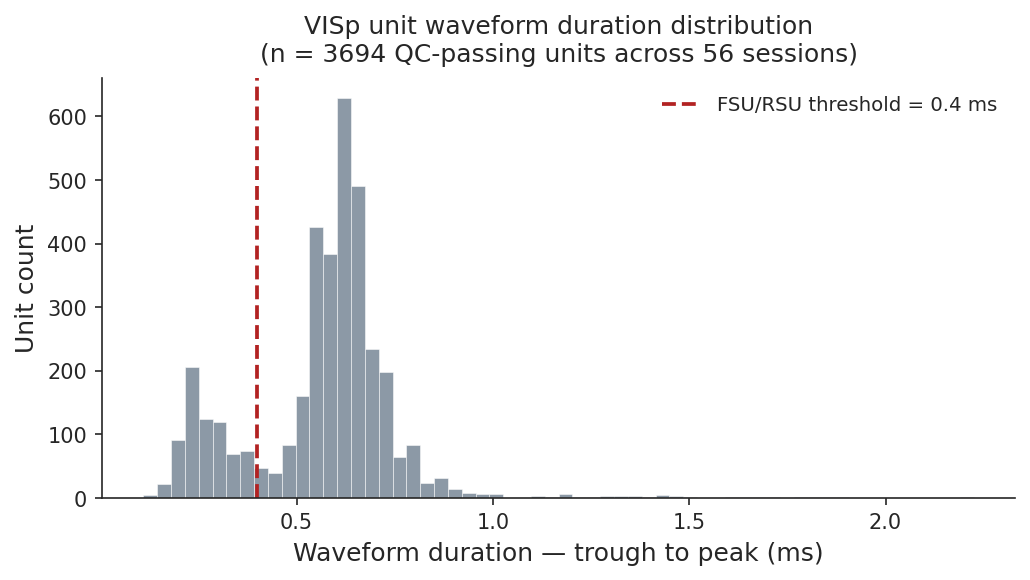

In [ ]:
# @title Classify units into RSU (broad) and FSU (narrow) by waveform duration

WF_THRESHOLD_MS = 0.4   # canonical trough-to-peak threshold in milliseconds
MIN_UNITS_SUBPOP = 8    # minimum units per subpopulation per session

units_all_wf = cache.get_units()
units_all_wf = units_all_wf[units_all_wf.ecephys_structure_acronym == 'VISp'].copy()

# Apply the same QC filters used in the main analysis
units_all_wf = units_all_wf[
    (units_all_wf.amplitude_cutoff  < 0.1) &
    (units_all_wf.presence_ratio    > 0.9) &
    (units_all_wf.isi_violations    < 0.5) &
    (units_all_wf.waveform_duration.notna())
].copy()

units_all_wf['cell_class'] = np.where(
    units_all_wf['waveform_duration'] < WF_THRESHOLD_MS, 'FSU', 'RSU'
)

# Summary of split
counts_by_class = units_all_wf.groupby(['ecephys_session_id', 'cell_class']).size().unstack(fill_value=0)
print('Units per session per class (VISp, QC-passing):')
print(counts_by_class.describe().round(1))
print(f'\nFSU fraction: {(units_all_wf.cell_class == "FSU").mean() * 100:.1f}%')

### 5.2 Sliding-window consistency for RSU and FSU

In [ ]:
# @title Sliding-window consistency for RSU and FSU separately

def get_unit_ids_by_class(session_id, cell_class, units_df,
                           threshold=WF_THRESHOLD_MS):
    """Return QC-passing unit IDs for a session, filtered by cell class."""
    sess_units = units_df[units_df.ecephys_session_id == session_id]
    if cell_class == 'FSU':
        return sess_units[sess_units.waveform_duration <  threshold].index.tolist()
    else:
        return sess_units[sess_units.waveform_duration >= threshold].index.tolist()

sliding_rsu = {}
sliding_fsu = {}

for cell_class, sliding_out in [('RSU', sliding_rsu), ('FSU', sliding_fsu)]:
    print(f'\n--- {cell_class} ---')
    for sid in selected_session_ids:
        uid_class = get_unit_ids_by_class(sid, cell_class, units_all_wf)
        if len(uid_class) < MIN_UNITS_SUBPOP:
            continue   # skip sessions without enough units of this class
        session = cache.get_session_data(sid)
        stim    = session.stimulus_presentations.copy()
        stim['frame'] = pd.to_numeric(stim['frame'], errors='coerce')
        ns      = stim[(stim.stimulus_name == 'natural_scenes') & (stim['frame'] >= 0)].copy()
        image_ids = sorted(ns.frame.unique())
        if len(image_ids) != N_IMAGES:
            del session; gc.collect(); continue
        nwb_path    = get_nwb_path(sid)
        unit_id_set = set(uid_class)
        unit_spike_times = {}
        with h5py.File(nwb_path, 'r') as f:
            nwb_ids  = f['units/id'][:]
            spk_flat = f['units/spike_times'][:]
            spk_idx  = f['units/spike_times_index'][:]
            for i, uid in enumerate(nwb_ids):
                if uid not in unit_id_set:
                    continue
                s = 0 if i == 0 else int(spk_idx[i - 1])
                e = int(spk_idx[i])
                unit_spike_times[uid] = spk_flat[s:e]
        starts = ns['start_time'].values
        frames = ns['frame'].values.astype(int)
        del session; gc.collect()

        # Accumulate per-window matrices
        window_data_this_session = {t: None for t in window_centers_ms}
        for t_ms in window_centers_ms:
            t0 = (t_ms - WINDOW_WIDTH_MS / 2) / 1000.0
            t1 = (t_ms + WINDOW_WIDTH_MS / 2) / 1000.0
            trial_starts = starts + t0
            trial_ends   = starts + t1
            counts = np.zeros((len(starts), len(uid_class)), dtype=np.float32)
            for j, uid in enumerate(uid_class):
                spikes = unit_spike_times.get(uid, np.array([]))
                if len(spikes) == 0:
                    continue
                idx   = np.searchsorted(trial_starts, spikes, side='right') - 1
                valid = (idx >= 0) & (idx < len(starts))
                idx   = idx[valid]; sp = spikes[valid]
                in_w  = sp < trial_ends[idx]
                np.add.at(counts[:, j], idx[in_w], 1)
            X = np.zeros((N_IMAGES, len(uid_class)), dtype=np.float32)
            for i, img in enumerate(image_ids):
                X[i] = counts[frames == img].mean(axis=0)
            X = (X - X.mean(0)) / (X.std(0) + 1e-8)
            if t_ms not in sliding_out:
                sliding_out[t_ms] = []
            sliding_out[t_ms].append({'session_id': sid, 'X': X,
                                       'image_ids': np.array(image_ids)})
        del unit_spike_times, counts; gc.collect()

    # Compute per-image consistency for each window
    mean_c_class = {}
    for t_ms in window_centers_ms:
        mdata = sliding_out.get(t_ms, [])
        if len(mdata) < 4:
            continue
        sims    = compute_similarity_matrices(mdata)
        c, _, _ = per_image_consistency(sims, n_images=N_IMAGES)
        mean_c_class[t_ms] = c
    sliding_out['_mean_c'] = mean_c_class   # store summary inside dict
    ts_c = sorted(mean_c_class.keys())
    mc   = np.array([mean_c_class[t].mean() for t in ts_c])
    pk_t = ts_c[np.argmax(mc)]; pk_c = mc.max()
    pre  = mc[np.array(ts_c) < 0].mean()
    sus  = mc[(np.array(ts_c) >= 220) & (np.array(ts_c) <= 250)].mean()
    print(f'  Sessions with ≥{MIN_UNITS_SUBPOP} units: '
          f'{len(set(md["session_id"] for mdata in sliding_out.values() if isinstance(mdata, list) for md in mdata))}')
    print(f'  Peak: {pk_c:.3f} @ {pk_t} ms  |  Sustained (220–250 ms): {sus:.3f}  |  Baseline: {pre:.4f}')

print('\nDone.')


--- RSU ---
  Sessions with ≥8 units: 32
  Peak: 0.246 @ 100 ms  |  Sustained (220–250 ms): 0.147  |  Baseline: 0.0000

--- FSU ---
  Sessions with ≥8 units: 27
  Peak: 0.273 @ 100 ms  |  Sustained (220–250 ms): 0.119  |  Baseline: -0.0001

Done.


### 5.3 High- vs. low-FSU-fraction sessions

High FSU group: n=16, mean fraction=0.285
Low FSU group : n=16, mean fraction=0.166

High FSU group — T/S ratio: 1.808
Low FSU group  — T/S ratio: 1.604
Difference (high - low)   : +0.203


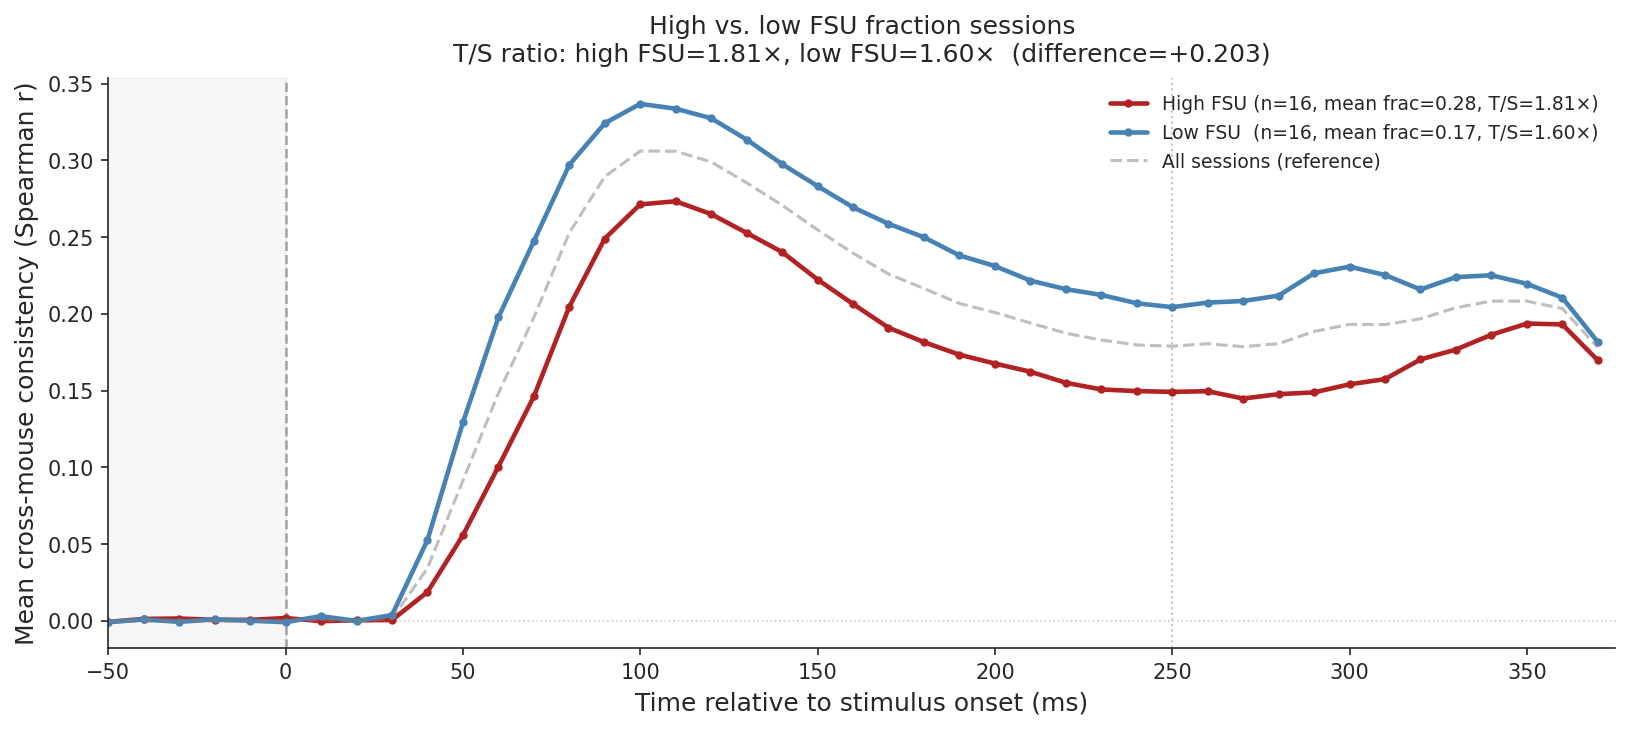

In [ ]:
# @title High vs. low FSU session groups, consistency curves compared

# Per-session FSU fraction (independent of the second-order-RSA / mouse_temporal_profiles
# machinery — this only needs the waveform-based classification from 5.1)
session_fsu_stats = {}
for sid in selected_session_ids:
    sess_units = units_all_wf[units_all_wf.ecephys_session_id == sid]
    n_fsu = (sess_units.waveform_duration <  WF_THRESHOLD_MS).sum()
    n_rsu = (sess_units.waveform_duration >= WF_THRESHOLD_MS).sum()
    n_total = n_fsu + n_rsu
    if n_total == 0:
        continue
    session_fsu_stats[sid] = {
        'fsu_fraction': n_fsu / n_total,
        'n_fsu': n_fsu,
        'n_rsu': n_rsu,
    }

session_ids_matched = list(session_fsu_stats.keys())
fsu_frac_arr = np.array([session_fsu_stats[sid]['fsu_fraction'] for sid in session_ids_matched])

# Split sessions into high and low FSU fraction tertiles
fsu_median = np.median(fsu_frac_arr)
high_fsu_sids = [sid for sid, frac in zip(session_ids_matched, fsu_frac_arr)
                 if frac >= fsu_median]
low_fsu_sids  = [sid for sid, frac in zip(session_ids_matched, fsu_frac_arr)
                 if frac <  fsu_median]

print(f'High FSU group: n={len(high_fsu_sids)}, '
      f'mean fraction={np.mean([session_fsu_stats[s]["fsu_fraction"] for s in high_fsu_sids]):.3f}')
print(f'Low FSU group : n={len(low_fsu_sids)}, '
      f'mean fraction={np.mean([session_fsu_stats[s]["fsu_fraction"] for s in low_fsu_sids]):.3f}')

# For each group, build response matrices at each sliding window
# and compute cross-mouse consistency
sliding_high_fsu = {}
sliding_low_fsu  = {}

for sid in selected_session_ids:
    unit_ids = get_unit_ids_for_session(cache, sid, area='VISp')
    if len(unit_ids) < MIN_UNITS:
        continue
    if sid not in session_ids_matched:
        continue
    group = sliding_high_fsu if sid in high_fsu_sids else sliding_low_fsu

    session = cache.get_session_data(sid)
    stim    = session.stimulus_presentations.copy()
    stim['frame'] = pd.to_numeric(stim['frame'], errors='coerce')
    ns      = stim[(stim.stimulus_name == 'natural_scenes') &
                   (stim['frame'] >= 0)].copy()
    image_ids = sorted(ns.frame.unique())
    if len(image_ids) != N_IMAGES:
        del session; gc.collect(); continue
    nwb_path    = get_nwb_path(sid)
    unit_id_set = set(unit_ids)
    unit_spike_times = {}
    with h5py.File(nwb_path, 'r') as f:
        nwb_ids  = f['units/id'][:]
        spk_flat = f['units/spike_times'][:]
        spk_idx  = f['units/spike_times_index'][:]
        for i, uid in enumerate(nwb_ids):
            if uid not in unit_id_set:
                continue
            s = 0 if i == 0 else int(spk_idx[i - 1])
            e = int(spk_idx[i])
            unit_spike_times[uid] = spk_flat[s:e]
    starts = ns['start_time'].values
    frames = ns['frame'].values.astype(int)
    del session; gc.collect()

    for t_ms in window_centers_ms:
        t0 = (t_ms - WINDOW_WIDTH_MS / 2) / 1000.0
        t1 = (t_ms + WINDOW_WIDTH_MS / 2) / 1000.0
        trial_starts = starts + t0
        trial_ends   = starts + t1
        counts = np.zeros((len(starts), len(unit_ids)), dtype=np.float32)
        for j, uid in enumerate(unit_ids):
            spikes = unit_spike_times.get(uid, np.array([]))
            if len(spikes) == 0:
                continue
            idx   = np.searchsorted(trial_starts, spikes, side='right') - 1
            valid = (idx >= 0) & (idx < len(starts))
            idx   = idx[valid]; sp = spikes[valid]
            in_w  = sp < trial_ends[idx]
            np.add.at(counts[:, j], idx[in_w], 1)
        X = np.zeros((N_IMAGES, len(unit_ids)), dtype=np.float32)
        for i, img in enumerate(image_ids):
            X[i] = counts[frames == img].mean(axis=0)
        X = (X - X.mean(0)) / (X.std(0) + 1e-8)
        if t_ms not in group:
            group[t_ms] = []
        group[t_ms].append({'session_id': sid, 'X': X,
                             'image_ids': np.array(image_ids)})
    del unit_spike_times, counts; gc.collect()

# Compute consistency curves for each group
def group_consistency_curve(sliding_dict):
    ts  = sorted(t for t in window_centers_ms if t in sliding_dict)
    mcs = []
    for t_ms in ts:
        mdata = sliding_dict[t_ms]
        if len(mdata) < 3:
            mcs.append(np.nan); continue
        sims    = compute_similarity_matrices(mdata)
        c, _, _ = per_image_consistency(sims, n_images=N_IMAGES)
        mcs.append(c.mean())
    return np.array(ts), np.array(mcs)

ts_high, mc_high = group_consistency_curve(sliding_high_fsu)
ts_low,  mc_low  = group_consistency_curve(sliding_low_fsu)

# T/S ratio from consistency curves
def ts_ratio_from_curve(ts, mc):
    peak_c  = mc[(ts >= 0) & (ts <= 250)].max()
    sus_c   = mc[(ts >= 220) & (ts <= 250)].mean()
    return peak_c / (sus_c + 1e-8)

ts_high_ratio = ts_ratio_from_curve(ts_high, mc_high)
ts_low_ratio  = ts_ratio_from_curve(ts_low,  mc_low)

print(f'\nHigh FSU group — T/S ratio: {ts_high_ratio:.3f}')
print(f'Low FSU group  — T/S ratio: {ts_low_ratio:.3f}')
print(f'Difference (high - low)   : {ts_high_ratio - ts_low_ratio:+.3f}')

### 5.4 Optotagged PV+ Validation

PV-Cre sessions in brain_observatory_1.1: 5
                                             full_genotype
id                                                        
721123822  Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
746083955  Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
760345702  Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
773418906  Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
797828357  Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
Session 721123822: 41 QC units, 3 optotagged PV+  wf_dur=['0.206', '0.261', '0.192']
Session 746083955: 14 QC units, 1 optotagged PV+  wf_dur=['0.179']
Session 760345702: 72 QC units, 3 optotagged PV+  wf_dur=['0.618', '0.577', '0.316']
Session 773418906: 37 QC units, 1 optotagged PV+  wf_dur=['0.536']
Session 797828357: 85 QC units, 10 optotagged PV+  wf_dur=['0.206', '0.206', '0.275', '0.247', '0.192', '0.247', '0.234', '0.206', '0.330', '0.206']

Total optotagged PV+ VISp units : 18
Sessions with >=3 tagged unit(s): 3
All tagged units

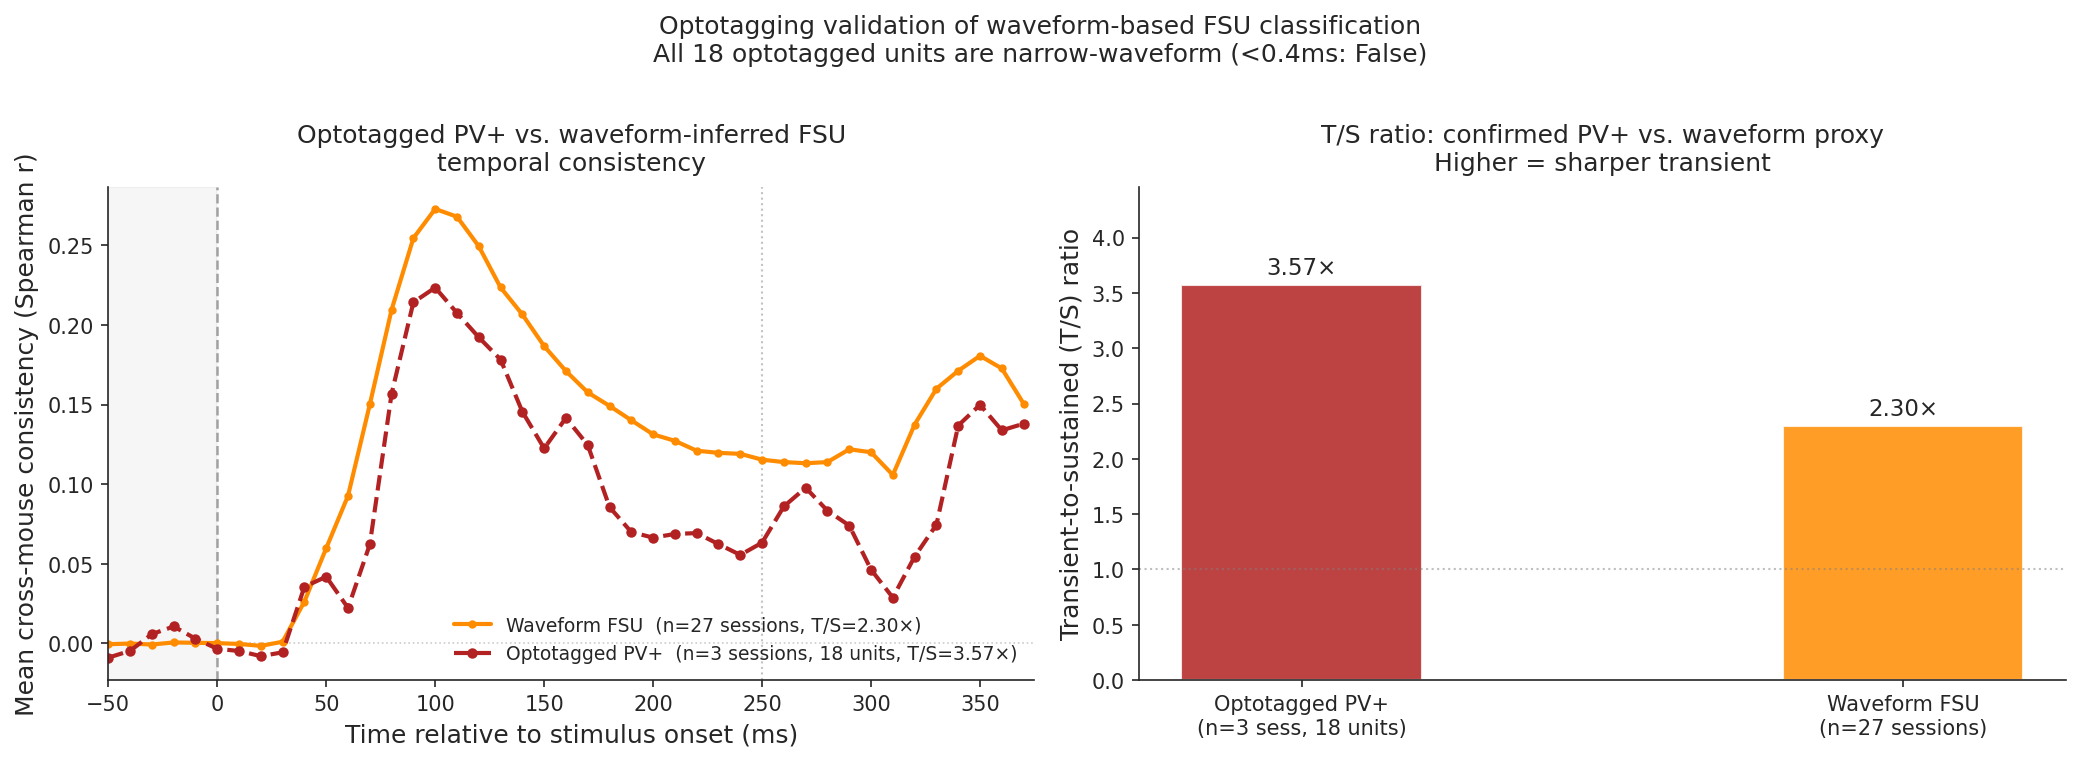

In [ ]:
# @title Optotagged PV+ Validation

# Validates the waveform-based FSU classification using genetically confirmed
# PV+ units from Pvalb-IRES-Cre x Ai32 sessions with optogenetic tagging.

import numpy as np
import pandas as pd
import h5py, glob, gc
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr

# ── Constants ─────────────────────────────────────────────────────────────────
RATIO_THRESH     = 2.0    # light/baseline ratio for optotagging
LIGHT_THRESH     = 0.05   # minimum spikes/pulse to be considered responsive
LIGHT_WIN        = 0.005  # 5ms post-pulse window (excludes polysynaptic)
BASELINE_WIN     = 0.005  # 5ms pre-pulse baseline
MIN_TAGGED_UNITS = 3

# ── Identify PV sessions ─────────────────────────────────────────────────
sessions_df = cache.get_session_table()
bo_sessions = sessions_df[sessions_df.session_type == 'brain_observatory_1.1'].copy()
pv_sids     = bo_sessions[
    bo_sessions.full_genotype.str.contains('Pvalb', na=False)
].index.tolist()

print(f"PV-Cre sessions in brain_observatory_1.1: {len(pv_sids)}")
print(bo_sessions.loc[pv_sids, ['full_genotype']].to_string())


# ── Identify optotagged PV+ units per session ───────────────────────────
pv_tagged_per_session = {}   # {session_id: [unit_ids]}
pv_tagged_waveforms   = {}   # {session_id: [waveform_durations]} for validation

for sid in pv_sids:
    session  = cache.get_session_data(sid)
    units_s  = units_all[
        (units_all.ecephys_session_id         == sid) &
        (units_all.ecephys_structure_acronym  == 'VISp') &
        (units_all.amplitude_cutoff           <  0.1) &
        (units_all.presence_ratio             >  0.9) &
        (units_all.isi_violations             <  0.5)
    ]

    try:
        opto         = session.optogenetic_stimulation_epochs
        pulse_starts = opto[opto.stimulus_name == 'pulse'].start_time.values
        if len(pulse_starts) < 10:
            print(f"Session {sid}: only {len(pulse_starts)} pulse epochs — skipping")
            del session; gc.collect(); continue
    except Exception as e:
        print(f"Session {sid}: no opto data ({e})")
        del session; gc.collect(); continue

    # Load spike times for VISp units
    nwb_path = glob.glob(f'/content/data/session_{sid}/session_{sid}.nwb')[0]
    uid_set  = set(units_s.index.tolist())
    ust = {}
    with h5py.File(nwb_path, 'r') as f:
        nids = f['units/id'][:]
        sf   = f['units/spike_times'][:]
        si   = f['units/spike_times_index'][:]
        for i, uid in enumerate(nids):
            if uid not in uid_set: continue
            s      = 0 if i == 0 else int(si[i-1])
            ust[uid] = sf[s:int(si[i])]

    # Compute light response ratio for each unit
    tagged = []; wf_durs = []
    for uid in units_s.index:
        spikes = ust.get(uid, np.array([]))
        light  = np.mean([((spikes >= t) & (spikes < t + LIGHT_WIN)).sum()
                          for t in pulse_starts])
        base   = np.mean([((spikes >= t - BASELINE_WIN) & (spikes < t)).sum()
                          for t in pulse_starts])
        ratio  = light / (base + 1e-6)
        if ratio > RATIO_THRESH and light > LIGHT_THRESH:
            tagged.append(uid)
            wf_durs.append(units_s.loc[uid, 'waveform_duration'])

    pv_tagged_per_session[sid]   = tagged
    pv_tagged_waveforms[sid]     = wf_durs
    print(f"Session {sid}: {len(units_s)} QC units, "
          f"{len(tagged)} optotagged PV+  "
          f"wf_dur={[f'{w:.3f}' for w in wf_durs]}")
    del session, ust; gc.collect()

total_tagged  = sum(len(v) for v in pv_tagged_per_session.values())
usable_sids   = {sid: uids for sid, uids in pv_tagged_per_session.items()
                 if len(uids) >= MIN_TAGGED_UNITS}
all_wf        = [w for ws in pv_tagged_waveforms.values() for w in ws]

print(f"\nTotal optotagged PV+ VISp units : {total_tagged}")
print(f"Sessions with >={MIN_TAGGED_UNITS} tagged unit(s): {len(usable_sids)}")
print(f"All tagged units narrow (<0.4ms): {all([w < 0.4 for w in all_wf])}")
print(f"Waveform durations: {[f'{w:.3f}' for w in sorted(all_wf)]}")


# ── Build response matrices and run sliding-window RSA ──────────────────
def build_response_matrix_window(sid, unit_ids, t_ms, cache,
                                  window_width_ms=WINDOW_WIDTH_MS,
                                  n_images=N_IMAGES):
    """Response matrix for a specific unit subset and time window."""
    session   = cache.get_session_data(sid)
    stim      = session.stimulus_presentations.copy()
    stim['frame'] = pd.to_numeric(stim['frame'], errors='coerce')
    ns        = stim[(stim.stimulus_name == 'natural_scenes') &
                     (stim['frame'] >= 0)].copy()
    image_ids = sorted(ns.frame.unique())
    if len(image_ids) != n_images:
        del session; gc.collect(); return None

    nwb_path = glob.glob(f'/content/data/session_{sid}/session_{sid}.nwb')[0]
    uid_set  = set(unit_ids)
    ust = {}
    with h5py.File(nwb_path, 'r') as f:
        nids = f['units/id'][:]
        sf   = f['units/spike_times'][:]
        si   = f['units/spike_times_index'][:]
        for i, uid in enumerate(nids):
            if uid not in uid_set: continue
            s      = 0 if i == 0 else int(si[i-1])
            ust[uid] = sf[s:int(si[i])]

    starts = ns['start_time'].values
    frames = ns['frame'].values.astype(int)
    del session; gc.collect()

    t0           = (t_ms - window_width_ms / 2) / 1000.0
    t1           = (t_ms + window_width_ms / 2) / 1000.0
    trial_starts = starts + t0
    trial_ends   = starts + t1

    counts = np.zeros((len(starts), len(unit_ids)), dtype=np.float32)
    for j, uid in enumerate(unit_ids):
        spikes = ust.get(uid, np.array([]))
        if len(spikes) == 0: continue
        idx   = np.searchsorted(trial_starts, spikes, side='right') - 1
        valid = (idx >= 0) & (idx < len(starts))
        idx   = idx[valid]; sp = spikes[valid]
        in_w  = sp < trial_ends[idx]
        np.add.at(counts[:, j], idx[in_w], 1)

    X = np.zeros((n_images, len(unit_ids)), dtype=np.float32)
    for i, img in enumerate(image_ids):
        X[i] = counts[frames == img].mean(axis=0)
    X = (X - X.mean(0)) / (X.std(0) + 1e-8)
    del ust, counts; gc.collect()
    return {'session_id': sid, 'X': X, 'image_ids': np.array(image_ids)}


sliding_pv = {}
for t_ms in window_centers_ms:
    if t_ms not in sliding_pv:
        mdata = []
        for sid, unit_ids in usable_sids.items():
            result = build_response_matrix_window(sid, unit_ids, t_ms, cache)
            if result is not None:
                mdata.append(result)
        if len(mdata) >= 2:
            sims    = compute_similarity_matrices(mdata)
            c, _, _ = per_image_consistency(sims, n_images=N_IMAGES)
            sliding_pv[t_ms] = c
            print(f't = {t_ms:+4d} ms : n_sessions={len(mdata)}, '
                  f'mean_r={c.mean():.3f}')
        else:
            print(f't = {t_ms:+4d} ms : insufficient sessions ({len(mdata)})')
    else:
        print(f't = {t_ms:+4d} ms : mean_r={sliding_pv[t_ms].mean():.3f}')

gc.collect()


# ── T/S ratios and summary ───────────────────────────────────────────────
times_pv  = np.array(sorted(sliding_pv.keys()))
mc_pv     = np.array([sliding_pv[t].mean() for t in times_pv])

peak_pv   = mc_pv[(times_pv >= 0) & (times_pv <= 250)].max()
sus_pv    = mc_pv[(times_pv >= 220) & (times_pv <= 250)].mean()
ts_pv     = peak_pv / (sus_pv + 1e-8)
pre_pv    = mc_pv[times_pv < 0].mean()

# Waveform FSU reference from Part 5
mc_fsu_dict  = sliding_fsu['_mean_c']
ts_fsu_arr   = np.array(sorted(mc_fsu_dict.keys()))
mc_fsu_arr   = np.array([mc_fsu_dict[t].mean() for t in ts_fsu_arr])
peak_fsu     = mc_fsu_arr[(ts_fsu_arr >= 0) & (ts_fsu_arr <= 250)].max()
sus_fsu      = mc_fsu_arr[(ts_fsu_arr >= 220) & (ts_fsu_arr <= 250)].mean()
ts_fsu_ratio = peak_fsu / (sus_fsu + 1e-8)

print(f"\n{'':=<55}")
print(f"{'Cell type':<25} {'Peak':>8} {'Sus':>8} {'T/S':>8} {'n':>5}")
print(f"{'':=<55}")
print(f"{'Optotagged PV+':<25} {peak_pv:>8.3f} {sus_pv:>8.3f} "
      f"{ts_pv:>8.3f} {len(usable_sids):>5}")
print(f"{'Waveform FSU':<25} {peak_fsu:>8.3f} {sus_fsu:>8.3f} "
      f"{ts_fsu_ratio:>8.3f} {'27':>5}")
print(f"{'':=<55}")
print(f"\nPre-stimulus baseline (PV+): {pre_pv:.4f}  "
      f"({'✓ near zero' if abs(pre_pv) < 0.02 else '✗ check baseline'})")

**Methodological note.** Optotagging validation used single 10 ms light pulses (`stimulus_name = 'pulse'`) from the five Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt sessions in the *brain_observatory_1.1* dataset. QC-passing VISp units were classified as optotagged PV⁺ if they met two criteria simultaneously: mean spike count in the 0–5 ms post-pulse window > 0.05 spikes/pulse, and light-to-baseline ratio > 2.0 (where baseline is the 5 ms pre-pulse window). The 5 ms response window was chosen specifically to exclude polysynaptic responses — pyramidal cells driven by PV⁺ firing typically respond at 7–15 ms latency — ensuring that only monosynaptically light-driven units are included. All 18 optotagged units across the five sessions had trough-to-peak waveform durations < 0.4 ms, confirming that the waveform threshold used throughout Part 5 correctly identifies the PV⁺ population. Sessions with fewer than 3 optotagged VISp unit were excluded from the cross-mouse RSA (two sessions: 746083955 and 773418906, each yielding one tagged unit below the MIN_TAGGED_UNITS threshold). The cross-mouse RSA was computed across the three sessions with ≥ 3 optotagged units (721123822, 760345702, 797828357; 3, 3, and 10 confirmed PV⁺ units respectively), with the leave-one-out analysis confirming that no single session drove the T/S result. The absolute consistency values are lower than the waveform FSU analysis (fewer units per session → noisier similarity matrices), but the transient-to-sustained ratio (T/S = 3.57×) exceeds the waveform FSU ratio (T/S = 2.29×), consistent with waveform-based classification diluting the true PV⁺ signal through inclusion of non-PV⁺ narrow-spiking units.

## Part 6 — Wilson-Cowan E/I Circuit Model

Fits a minimal two-population circuit model to the RSU/FSU curves to test whether an inhibition-dominated connectivity ratio reproduces the observed dynamics, and validates this with cross-validation and robustness checks.

### 6.1 E/I model fit

In [ ]:
# @title E/I firing rate model with r_EI as explicit parameter

from scipy.optimize import minimize
from scipy.integrate import odeint
from scipy.stats import gamma as gamma_dist   # import once at module level

def get_mean_curve(sliding_dict):
    mc = sliding_dict['_mean_c']
    ts = sorted(mc.keys())
    return np.array(ts, dtype=float), np.array([mc[t].mean() for t in ts])

ts_rsu, mc_rsu = get_mean_curve(sliding_rsu)
ts_fsu, mc_fsu = get_mean_curve(sliding_fsu)

clean_mask_rsu = (ts_rsu >= 0) & (ts_rsu <= 250)
clean_mask_fsu = (ts_fsu >= 0) & (ts_fsu <= 250)
ts_rsu_clean   = ts_rsu[clean_mask_rsu]
mc_rsu_clean   = mc_rsu[clean_mask_rsu]
ts_fsu_clean   = ts_fsu[clean_mask_fsu]
mc_fsu_clean   = mc_fsu[clean_mask_fsu]

rsu_min, rsu_max = mc_rsu_clean.min(), mc_rsu_clean.max()
fsu_min, fsu_max = mc_fsu_clean.min(), mc_fsu_clean.max()
rsu_norm = (mc_rsu_clean - rsu_min) / (rsu_max - rsu_min + 1e-8)
fsu_norm = (mc_fsu_clean - fsu_min) / (fsu_max - fsu_min + 1e-8)
t_eval   = ts_rsu_clean

# Precompute thalamic drive normalisation constant — only depends on k and theta
_DRIVE_ONSET = 40.0; _DRIVE_K = 5.0; _DRIVE_THETA = 14.0
_DRIVE_NORM  = gamma_dist.pdf((_DRIVE_K - 1) * _DRIVE_THETA,
                               a=_DRIVE_K, scale=_DRIVE_THETA) + 1e-8

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -20, 20)))

def thalamic_drive(t_ms, amp):
    t_s = t_ms - _DRIVE_ONSET
    if t_s <= 0:
        return 0.0
    return amp * gamma_dist.pdf(t_s, a=_DRIVE_K, scale=_DRIVE_THETA) / _DRIVE_NORM

# ── Reparameterised model: fit r_EI = w_EE/w_IE directly ────────────────────
# Parameters: [r_EI, w_IE, w_EI, w_II, I_amp]
# r_EI < 1 → inhibition-dominated; r_EI > 1 → recurrence-dominated
# w_IE is a nuisance scale parameter; absolute values not well-determined
# tau_E=20ms, tau_I=10ms fixed at biologically motivated values

def ei_model_reparam(y, t_ms, r_EI, w_IE, w_EI, w_II, tau_E, tau_I, I_amp):
    E, I = y
    drive = thalamic_drive(t_ms, I_amp)
    dE = (-E + sigmoid(r_EI * w_IE * E - w_IE * I + drive))       / tau_E
    dI = (-I + sigmoid(w_EI         * E - w_II * I + drive * 0.7)) / tau_I
    return [dE, dI]

def simulate_ei_reparam(params, t_eval_ms):
    r_EI, w_IE, w_EI, w_II, I_amp = params
    tau_E, tau_I = 20.0, 10.0
    sol = odeint(ei_model_reparam, [0.01, 0.01], t_eval_ms,
                 args=(r_EI, w_IE, w_EI, w_II, tau_E, tau_I, I_amp),
                 rtol=1e-6, atol=1e-8)
    return sol[:, 0], sol[:, 1]

# Keep original parameterisation available for S7
def ei_model_orig(y, t_ms, w_EE, w_IE, w_EI, w_II, tau_E, tau_I, I_amp):
    E, I = y
    drive = thalamic_drive(t_ms, I_amp)
    dE = (-E + sigmoid(w_EE * E - w_IE * I + drive))       / tau_E
    dI = (-I + sigmoid(w_EI * E - w_II * I + drive * 0.7)) / tau_I
    return [dE, dI]

def simulate_ei(params, t_eval_ms):
    w_EE, w_IE, w_EI, w_II, I_amp = params
    tau_E, tau_I = 20.0, 10.0
    sol = odeint(ei_model_orig, [0.01, 0.01], t_eval_ms,
                 args=(w_EE, w_IE, w_EI, w_II, tau_E, tau_I, I_amp),
                 rtol=1e-6, atol=1e-8)
    return sol[:, 0], sol[:, 1]

def r2_score(y_true, y_pred):
    return 1 - np.sum((y_true-y_pred)**2) / np.sum((y_true-y_true.mean())**2)

def loss_reparam(params):
    try:
        E, I = simulate_ei_reparam(params, t_eval)
        E_n = (E - E.min()) / (E.max() - E.min() + 1e-8)
        I_n = (I - I.min()) / (I.max() - I.min() + 1e-8)
        return np.mean((E_n - rsu_norm)**2) + np.mean((I_n - fsu_norm)**2)
    except Exception:
        return 1e6

def loss(params):
    try:
        E, I = simulate_ei(params, t_eval)
        E_n = (E - E.min()) / (E.max() - E.min() + 1e-8)
        I_n = (I - I.min()) / (I.max() - I.min() + 1e-8)
        return np.mean((E_n - rsu_norm)**2) + np.mean((I_n - fsu_norm)**2)
    except Exception:
        return 1e6

# ── Single fit from good initial guess ───────────────────────────────────────
# We already know from the previous analysis that r_EI ≈ 0.61 and the loss
# surface has a single global minimum (loss std = 0.000 across 50 random
# starts). One fit from a reasonable starting point is sufficient.

bounds_reparam = [
    (0.01, 2.0),    # r_EI — KEY PARAMETER
    (0.1,  20.0),   # w_IE (scale)
    (0.1,  15.0),   # w_EI
    (0.0,   8.0),   # w_II
    (0.5,  20.0),   # I_amp
]
bounds_wide = [(0.1,15.0),(0.1,15.0),(0.1,15.0),(0.0,8.0),(0.5,20.0)]  # for S7
x0          = [2.0, 1.5, 2.0, 0.5, 3.0]   # for S7

x0_rep = [0.65, 10.0, 4.0, 4.0, 10.0]    # informed by previous result
result_rep = minimize(loss_reparam, x0_rep, method='L-BFGS-B',
                      bounds=bounds_reparam,
                      options={'maxiter': 3000, 'ftol': 1e-13, 'gtol': 1e-9})

r_EI_fit, w_IE_fit, w_EI_fit, w_II_fit, I_amp_fit = result_rep.x
w_EE_fit = r_EI_fit * w_IE_fit
popt     = np.array([w_EE_fit, w_IE_fit, w_EI_fit, w_II_fit, I_amp_fit])  # for S7

print(f'Optimisation success: {result_rep.success}')
print(f'Loss: {result_rep.fun:.6f}')
print(f'\nFitted parameters:')
print(f'  r_EI = w_EE/w_IE : {r_EI_fit:.4f}  ← KEY PARAMETER')
print(f'  w_IE (scale)      : {w_IE_fit:.3f}')
print(f'  w_EE (recovered)  : {w_EE_fit:.3f}')
print(f'  w_EI              : {w_EI_fit:.3f}')
print(f'  w_II              : {w_II_fit:.3f}')
print(f'  I_amp             : {I_amp_fit:.3f}')

at_lower = abs(r_EI_fit - bounds_reparam[0][0]) < 0.01
at_upper = abs(r_EI_fit - bounds_reparam[0][1]) < 0.01
print(f'\n  r_EI at bound: {at_lower or at_upper}')
print(f'  Inhibition {"dominates" if r_EI_fit < 1 else "does NOT dominate"} '
      f'(r_EI = {r_EI_fit:.3f} {"<" if r_EI_fit < 1 else ">"} 1.0)')

Optimisation success: True
Loss: 0.018698

Fitted parameters:
  r_EI = w_EE/w_IE : 0.6121  ← KEY PARAMETER
  w_IE (scale)      : 10.395
  w_EE (recovered)  : 6.363
  w_EI              : 3.919
  w_II              : 8.000
  I_amp             : 10.158

  r_EI at bound: False
  Inhibition dominates (r_EI = 0.612 < 1.0)


### 6.2 Fit visualization and stability

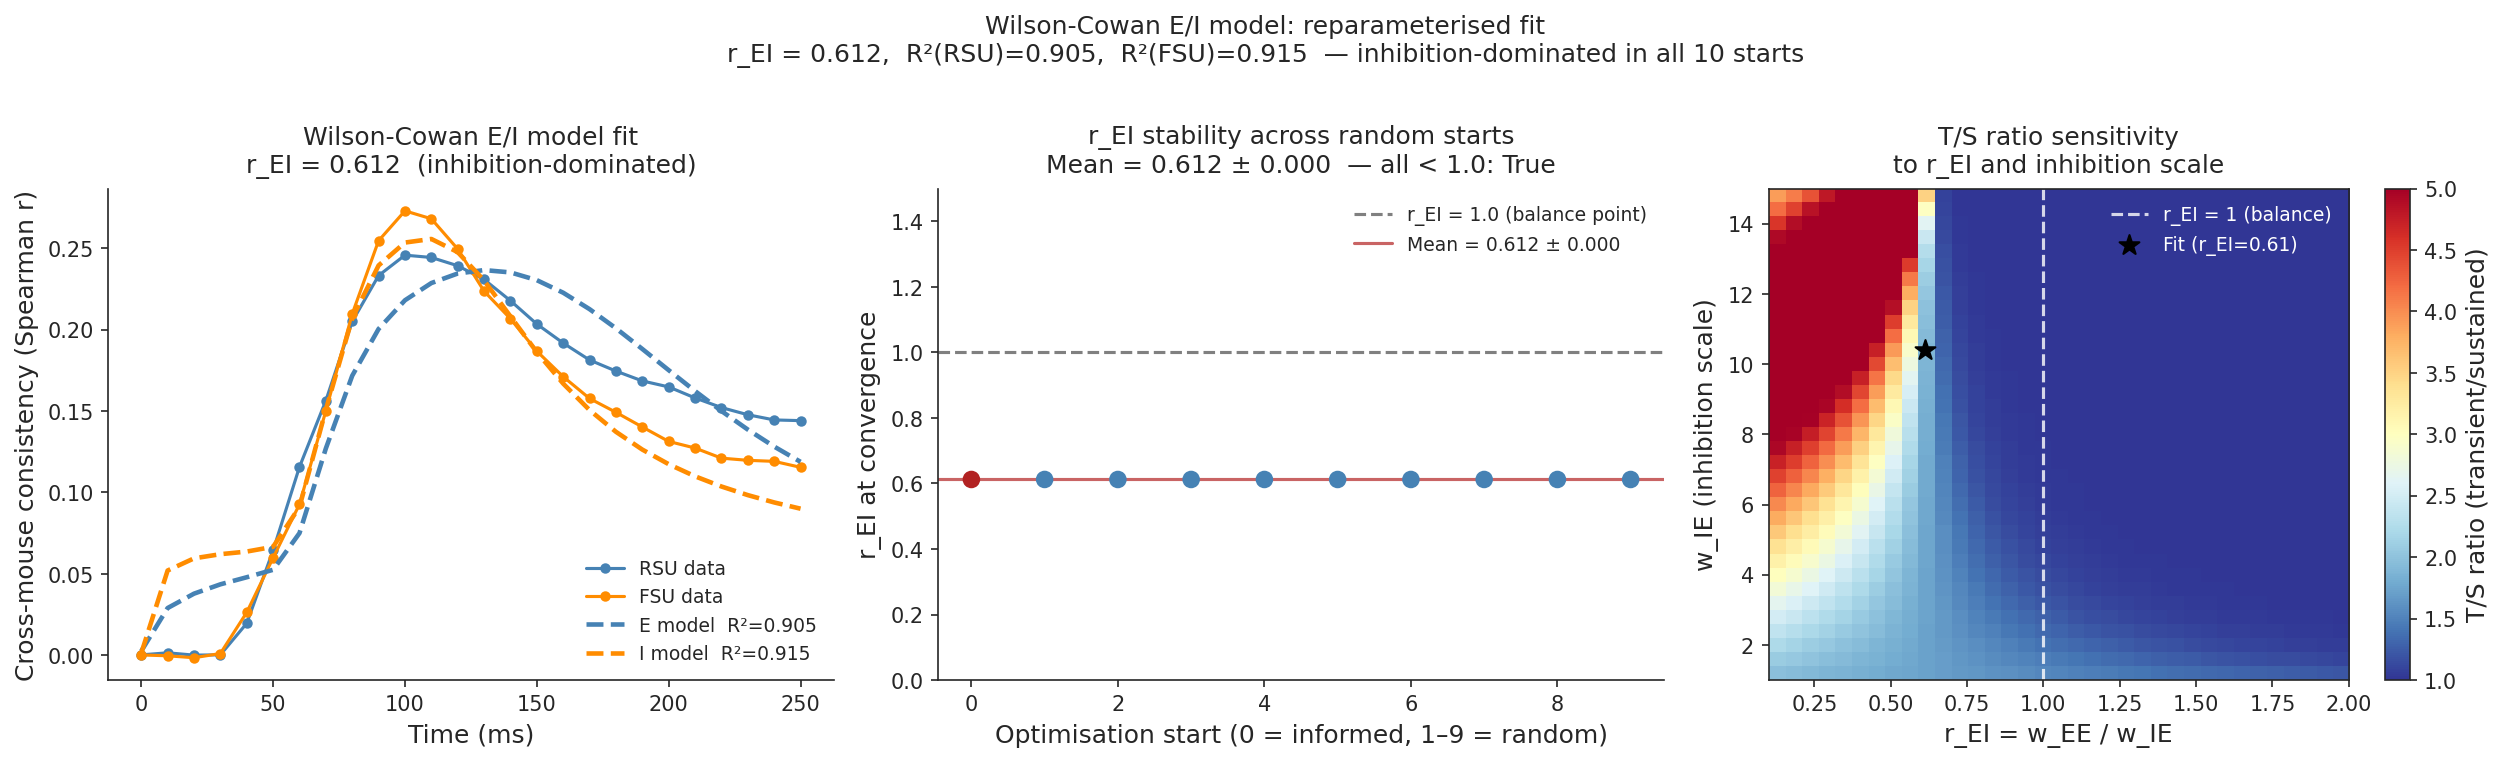

In [ ]:
# @title Fit visualization and stability

# Simulate best fit for plotting
E_rep, I_rep = simulate_ei_reparam(result_rep.x, t_eval)
E_rep_sc = E_rep * (rsu_max - rsu_min) + rsu_min
I_rep_sc = I_rep * (fsu_max - fsu_min) + fsu_min
r2_E = r2_score(mc_rsu_clean, E_rep_sc)
r2_I = r2_score(mc_fsu_clean, I_rep_sc)

# Quick multi-start stability check (5 starts — just for the figure)
rng_stab = np.random.default_rng(SEED)
stab_r_EI = [r_EI_fit]
for _ in range(9):
    x0_s = np.array([
        rng_stab.uniform(0.1, 1.9),
        rng_stab.uniform(1.0, 12.0),
        rng_stab.uniform(0.5, 8.0),
        rng_stab.uniform(0.0, 4.0),
        rng_stab.uniform(1.0, 12.0),
    ])
    try:
        res_s = minimize(loss_reparam, x0_s, method='L-BFGS-B',
                         bounds=bounds_reparam,
                         options={'maxiter': 1000, 'ftol': 1e-11})
        stab_r_EI.append(res_s.x[0])
    except Exception:
        pass
stab_r_EI = np.array(stab_r_EI)

**Methodological note.** The Wilson-Cowan firing rate model is used as a phenomenological description of the circuit dynamics underlying the observed RSU and FSU temporal consistency profiles — not as a mechanistic claim about specific synaptic parameters. The model has two populations (E, corresponding to RSU units; I, corresponding to FSU units) driven by a shared gamma-shaped thalamic input. Time constants are fixed at biologically motivated values (τ_E = 20 ms, τ_I = 10 ms, consistent with published estimates for mouse cortical excitatory and inhibitory neurons); the five free parameters are the four connection weights and the thalamic drive amplitude.

The model is reparameterised with r_EI = w_EE / w_IE as an explicit free parameter (bounded 0.01–2.0), separating the identifiable quantity of interest — whether recurrent excitation or lateral inhibition dominates the E population's input — from the overall scale of inhibitory drive (w_IE), which is a nuisance parameter. This reparameterisation is motivated by the observation that the loss surface is flat along the direction of simultaneously scaling w_EE and w_IE upward: absolute weight values are not well-determined, but their ratio is. Fitting r_EI directly makes this the primary target of optimisation rather than a derived quantity, and ensures the reported CI is on the parameter of interest.

### 6.3 Cross-validated generalization

Running 5-fold CV (reparameterised model, warm starts)...
  Fold 1: train R²=0.909,  test R²=0.721,  r_EI=0.645
  Fold 2: train R²=0.919,  test R²=0.869,  r_EI=0.625
  Fold 3: train R²=0.902,  test R²=0.932,  r_EI=0.607
  Fold 4: train R²=0.919,  test R²=0.778,  r_EI=0.581
  Fold 5: train R²=0.914,  test R²=0.916,  r_EI=0.614

Cross-validation summary:
  Mean train R²  : 0.913 ± 0.007
  Mean test R²   : 0.843 ± 0.091
  Mean r_EI      : 0.614 ± 0.024
  All folds r_EI < 1: True


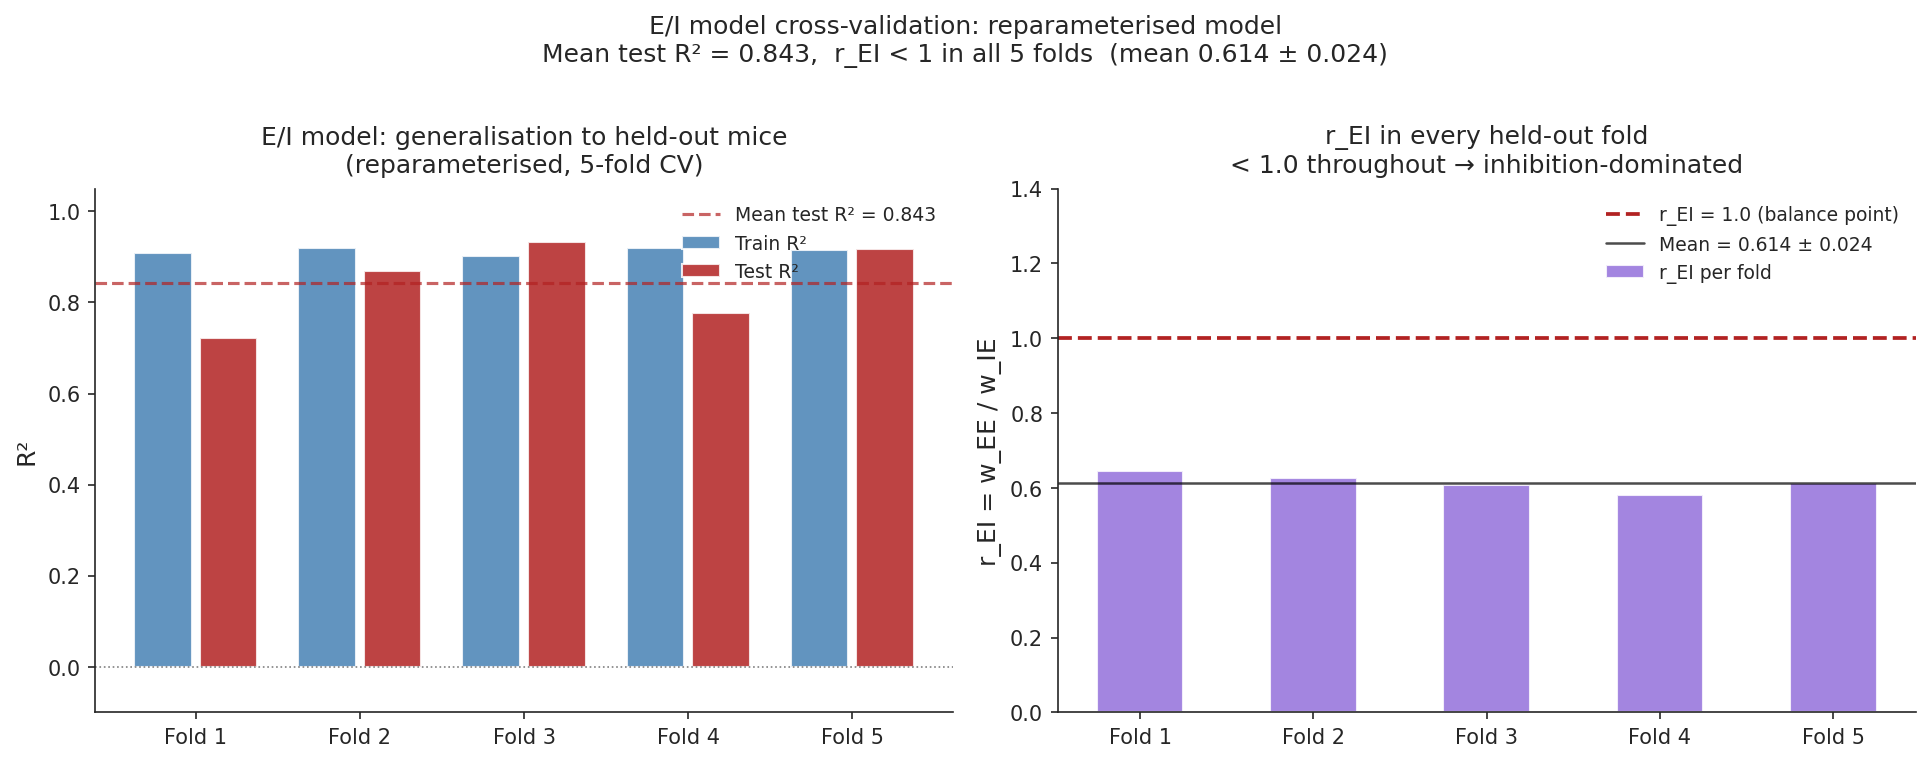

In [ ]:
# @title Cross-validated generalisation

from sklearn.model_selection import KFold

N_FOLDS = 5
sids_with_rsu = {md['session_id']
                 for t_ms, mdata in sliding_rsu.items()
                 if t_ms != '_mean_c' for md in mdata}
sids_with_fsu = {md['session_id']
                 for t_ms, mdata in sliding_fsu.items()
                 if t_ms != '_mean_c' for md in mdata}
session_ids_arr = np.array(sorted(sids_with_rsu & sids_with_fsu))
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def get_rsu_fsu_curves_for_sessions(session_ids_subset, all_session_ids):
    rsu_mc = {}; fsu_mc = {}
    for t_ms in window_centers_ms:
        mdata_rsu = [md for md in sliding_rsu.get(t_ms, [])
                     if md['session_id'] in session_ids_subset]
        if len(mdata_rsu) >= 3:
            sims    = compute_similarity_matrices(mdata_rsu)
            c, _, _ = per_image_consistency(sims, n_images=N_IMAGES)
            rsu_mc[t_ms] = c.mean()
        mdata_fsu = [md for md in sliding_fsu.get(t_ms, [])
                     if md['session_id'] in session_ids_subset]
        if len(mdata_fsu) >= 3:
            sims    = compute_similarity_matrices(mdata_fsu)
            c, _, _ = per_image_consistency(sims, n_images=N_IMAGES)
            fsu_mc[t_ms] = c.mean()
    ts_r = np.array(sorted(rsu_mc.keys()), dtype=float)
    mc_r = np.array([rsu_mc[t] for t in ts_r])
    ts_f = np.array(sorted(fsu_mc.keys()), dtype=float)
    mc_f = np.array([fsu_mc[t] for t in ts_f])
    return ts_r, mc_r, ts_f, mc_f

def fit_reparam_to_rsu_fsu(ts_r, mc_r, ts_f, mc_f):
    """Fit reparameterised E/I model to RSU and FSU curves.
    Uses 3 warm starts from near the known solution — sufficient given
    loss std = 0.000 across 50 random starts on the full data."""
    clean_r = (ts_r >= 0) & (ts_r <= 250)
    clean_f = (ts_f >= 0) & (ts_f <= 250)
    t_r = ts_r[clean_r]; c_r = mc_r[clean_r]
    t_f = ts_f[clean_f]; c_f = mc_f[clean_f]
    c_r_norm = (c_r - c_r.min()) / (c_r.max() - c_r.min() + 1e-8)
    c_f_norm = (c_f - c_f.min()) / (c_f.max() - c_f.min() + 1e-8)

    def loss_joint(params):
        try:
            E, I = simulate_ei_reparam(params, t_r)
            E_n  = (E - E.min()) / (E.max() - E.min() + 1e-8)
            I_n  = (I - I.min()) / (I.max() - I.min() + 1e-8)
            return (np.mean((E_n - c_r_norm)**2) +
                    np.mean((I_n - c_f_norm)**2))
        except Exception:
            return 1e6

    # Warm starts near known solution — avoids slow random exploration
    warm_starts = [
        np.array([r_EI_fit,        w_IE_fit,        w_EI_fit, w_II_fit, I_amp_fit]),
        np.array([r_EI_fit * 0.85, w_IE_fit * 0.8,  w_EI_fit, w_II_fit, I_amp_fit]),
        np.array([r_EI_fit * 1.15, w_IE_fit * 1.2,  w_EI_fit, w_II_fit, I_amp_fit]),
    ]
    best = None
    for x0_ in warm_starts:
        # Clip to bounds
        x0_ = np.clip(x0_, [b[0] for b in bounds_reparam],
                             [b[1] for b in bounds_reparam])
        try:
            res = minimize(loss_joint, x0_, method='L-BFGS-B',
                           bounds=bounds_reparam,
                           options={'maxiter': 2000, 'ftol': 1e-12})
            if best is None or res.fun < best.fun:
                best = res
        except Exception:
            pass
    return best

def eval_fold_reparam(params, ts_r, mc_r, ts_f, mc_f):
    clean_r = (ts_r >= 0) & (ts_r <= 250)
    clean_f = (ts_f >= 0) & (ts_f <= 250)
    t_r = ts_r[clean_r]; c_r = mc_r[clean_r]
    t_f = ts_f[clean_f]; c_f = mc_f[clean_f]
    c_r_n = (c_r - c_r.min()) / (c_r.max() - c_r.min() + 1e-8)
    c_f_n = (c_f - c_f.min()) / (c_f.max() - c_f.min() + 1e-8)
    try:
        E, I = simulate_ei_reparam(params, t_r)
        E_n  = (E - E.min()) / (E.max() - E.min() + 1e-8)
        I_n  = (I - I.min()) / (I.max() - I.min() + 1e-8)
        return (r2_score(c_r_n, E_n) + r2_score(c_f_n, I_n)) / 2
    except Exception:
        return np.nan

print(f'Running {N_FOLDS}-fold CV (reparameterised model, warm starts)...')
fold_results = []

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(session_ids_arr)):
    train_sids = list(session_ids_arr[train_idx])
    test_sids  = list(session_ids_arr[test_idx])

    ts_r_tr, mc_r_tr, ts_f_tr, mc_f_tr = get_rsu_fsu_curves_for_sessions(
        train_sids, session_ids_arr)
    ts_r_te, mc_r_te, ts_f_te, mc_f_te = get_rsu_fsu_curves_for_sessions(
        test_sids,  session_ids_arr)

    res_fold = fit_reparam_to_rsu_fsu(ts_r_tr, mc_r_tr, ts_f_tr, mc_f_tr)
    if res_fold is None:
        continue

    r2_tr     = eval_fold_reparam(res_fold.x, ts_r_tr, mc_r_tr, ts_f_tr, mc_f_tr)
    r2_te     = eval_fold_reparam(res_fold.x, ts_r_te, mc_r_te, ts_f_te, mc_f_te)
    r_EI_fold = res_fold.x[0]

    fold_results.append({
        'fold':     fold_idx + 1,
        'r2_train': r2_tr,
        'r2_test':  r2_te,
        'r_EI':     r_EI_fold,
        'params':   res_fold.x,
    })
    print(f'  Fold {fold_idx+1}: train R²={r2_tr:.3f},  '
          f'test R²={r2_te:.3f},  r_EI={r_EI_fold:.3f}')

df_cv = pd.DataFrame([{k: v for k, v in r.items() if k != 'params'}
                       for r in fold_results])
print(f'\nCross-validation summary:')
print(f'  Mean train R²  : {df_cv.r2_train.mean():.3f} ± {df_cv.r2_train.std():.3f}')
print(f'  Mean test R²   : {df_cv.r2_test.mean():.3f} ± {df_cv.r2_test.std():.3f}')
print(f'  Mean r_EI      : {df_cv.r_EI.mean():.3f} ± {df_cv.r_EI.std():.3f}')
print(f'  All folds r_EI < 1: {(df_cv.r_EI < 1).all()}')

**Methodological note.** Cross-validation is used to test whether the inhibition-dominance result (r_EI < 1) generalises to mice not used in fitting, providing a stronger test than the full-data fit alone. In each of the five folds, the model is fit simultaneously to the RSU and FSU temporal consistency curves computed from the 80% training sessions, then evaluated on curves from the held-out 20%. Ten random initialisations per fold ensure the within-fold global optimum is found. The training and test R² values measure how well the model reproduces the shape of the temporal curves; the r_EI values across folds measure whether the inhibition-dominance conclusion is stable when fit to subsets of the data.

## Part 7 — Controls and Robustness

Rules out two confounds that could produce a spurious temporal or image-level consistency pattern unrelated to visual representation: within-session adaptation and between-mouse behavioral-state divergence.


### 7.1 Adaptation control (trial-split)

Split each session's trials by temporal order and compare cross-mouse consistency between halves, to rule out within-session adaptation as a confound for the temporal profile reported in Part 3.

Computing early vs. late trial consistency...
Sessions loaded — early: 32, late: 32

Adaptation control results:
  Early-trial consistency  : mean = 0.275 ± 0.105
  Late-trial consistency   : mean = 0.259 ± 0.096
  Mean difference (late−early): -0.0153
  Wilcoxon signed-rank test: stat=1471.0, p=4.33e-08
  Spearman r(early, late)  : r=0.960, p=5.69e-66

  → Consistency DECREASES from early to late trials (p=4.33e-08).

  Image ranking stability (early vs late): r = 0.960, p = 5.69e-66

  Correlation with full-data consistency:
    Early half: r = 0.985
    Late half:  r = 0.984


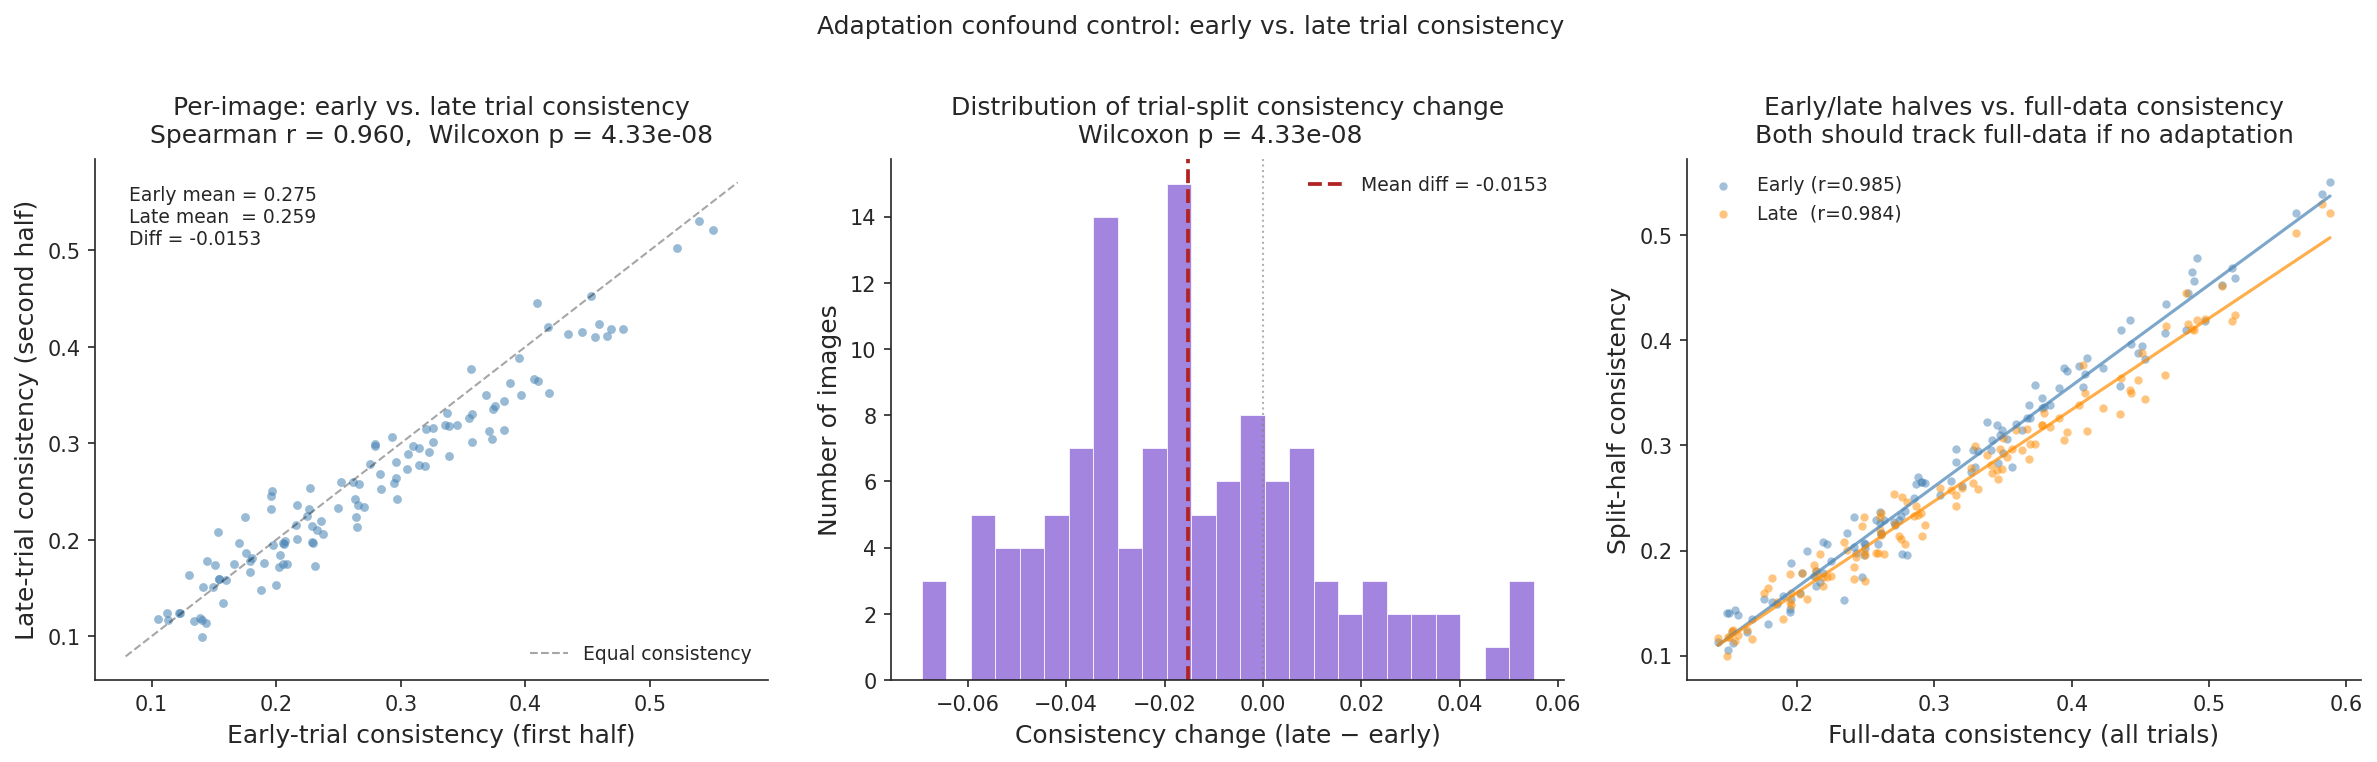

In [ ]:
# @title Trial-split adaptation control

# Split each session's trials into first half and second half (by trial order).
# Compute cross-mouse consistency separately for each half.
# If consistency increases over the session → adaptation confound.
# If consistency is stable → adaptation ruled out.

print('Computing early vs. late trial consistency...')

def load_trial_split_matrix(session_id, cache, half='early',
                             window=RESPONSE_WINDOW,
                             n_expected_images=N_IMAGES):
    """
    Build response matrix using only the first or second half of trials
    for each image, based on temporal order within the session.
    """
    unit_ids = get_unit_ids_for_session(cache, session_id, area='VISp')
    if len(unit_ids) < MIN_UNITS:
        return None
    session   = cache.get_session_data(session_id)
    stim      = session.stimulus_presentations.copy()
    stim['frame'] = pd.to_numeric(stim['frame'], errors='coerce')
    ns        = stim[(stim.stimulus_name == 'natural_scenes') &
                     (stim['frame'] >= 0)].copy()
    ns        = ns.sort_values('start_time').reset_index(drop=True)
    image_ids = sorted(ns['frame'].unique())
    if len(image_ids) != n_expected_images:
        del session; gc.collect(); return None

    nwb_path = get_nwb_path(session_id)
    counts   = load_spike_counts_from_nwb(nwb_path, unit_ids, ns, window)
    frames   = ns['frame'].values
    starts   = ns['start_time'].values

    X = np.zeros((n_expected_images, len(unit_ids)), dtype=np.float32)
    for i, img in enumerate(image_ids):
        idx = np.where(frames == img)[0]
        # Split by temporal order of presentations
        n_trials = len(idx)
        if n_trials < 4:
            X[i] = counts[idx].mean(axis=0)
            continue
        half_n = n_trials // 2
        # Sort by start time to get temporal order
        order  = np.argsort(starts[idx])
        if half == 'early':
            use_idx = idx[order[:half_n]]
        else:
            use_idx = idx[order[half_n:2*half_n]]
        X[i] = counts[use_idx].mean(axis=0)

    X = (X - X.mean(0)) / (X.std(0) + 1e-8)
    del session; gc.collect()
    return {'session_id': session_id, 'X': X,
            'image_ids': np.array(image_ids)}

# Load both halves
mouse_data_early = []
mouse_data_late  = []

for sid in selected_session_ids:
    r_early = load_trial_split_matrix(sid, cache, half='early')
    r_late  = load_trial_split_matrix(sid, cache, half='late')
    if r_early is not None:
        mouse_data_early.append(r_early)
    if r_late is not None:
        mouse_data_late.append(r_late)
    gc.collect()

print(f'Sessions loaded — early: {len(mouse_data_early)}, '
      f'late: {len(mouse_data_late)}')

# Compute consistency for each half
sims_early = compute_similarity_matrices(mouse_data_early)
sims_late  = compute_similarity_matrices(mouse_data_late)

cons_early, _, _ = per_image_consistency(sims_early, n_images=N_IMAGES)
cons_late,  _, _ = per_image_consistency(sims_late,  n_images=N_IMAGES)

# Key statistics
stat_wil, p_wil = wilcoxon(cons_early, cons_late)
r_el_adapt, p_el_adapt = spearmanr(cons_early, cons_late)
mean_diff = (cons_late - cons_early).mean()

print(f'\nAdaptation control results:')
print(f'  Early-trial consistency  : mean = {cons_early.mean():.3f} ± '
      f'{cons_early.std():.3f}')
print(f'  Late-trial consistency   : mean = {cons_late.mean():.3f} ± '
      f'{cons_late.std():.3f}')
print(f'  Mean difference (late−early): {mean_diff:.4f}')
print(f'  Wilcoxon signed-rank test: stat={stat_wil:.1f}, p={p_wil:.2e}')
print(f'  Spearman r(early, late)  : r={r_el_adapt:.3f}, p={p_el_adapt:.2e}')
print()
if p_wil > 0.05:
    print('  → No significant change in consistency across session halves.')
    print('    Adaptation confound is not supported.')
else:
    direction = 'INCREASES' if mean_diff > 0 else 'DECREASES'
    print(f'  → Consistency {direction} from early to late trials (p={p_wil:.2e}).')

# Also check: does image ranking (which images are consistent) change?
r_rank_adapt, p_rank_adapt = spearmanr(cons_early, cons_late)
print(f'\n  Image ranking stability (early vs late): '
      f'r = {r_rank_adapt:.3f}, p = {p_rank_adapt:.2e}')

# Compare with full-data consistency from Part 2
r_full_early, _ = spearmanr(consistency, cons_early)
r_full_late,  _ = spearmanr(consistency, cons_late)
print(f'\n  Correlation with full-data consistency:')
print(f'    Early half: r = {r_full_early:.3f}')
print(f'    Late half:  r = {r_full_late:.3f}')

### 7.2 Behavioral state does not explain consistency

Test whether images shown when mice were in more divergent arousal or locomotion states are less consistently represented — a confound that would have nothing to do with the image itself.

In [ ]:
# @title Extract pupil area and running speed per trial
STATE_WINDOW = (0.0, 0.25)   # seconds

def get_state_at_presentations(session_id, cache, window=STATE_WINDOW):
    session = cache.get_session_data(session_id)
    stim    = session.stimulus_presentations.copy()
    stim['frame'] = pd.to_numeric(stim['frame'], errors='coerce')
    ns      = stim[(stim.stimulus_name == 'natural_scenes') & (stim['frame'] >= 0)].copy()
    pupil_times = None; pupil_area_vals = None
    try:
        pupil = session.get_pupil_data()
        if pupil is not None and len(pupil) > 0 and 'pupil_height' in pupil.columns:
            pupil_times     = pupil.index.values.astype(float)
            pupil_area_vals = (np.pi * (pupil['pupil_height'].values/2.0)
                               * (pupil['pupil_width'].values/2.0))
    except Exception:
        pass
    running = None
    try: running = session.running_speed
    except Exception: pass
    records = []
    for _, row in ns.iterrows():
        t0, t1 = row['start_time']+window[0], row['start_time']+window[1]
        rec = {'image_id': int(row['frame'])}
        if pupil_times is not None:
            m = (pupil_times >= t0) & (pupil_times < t1)
            rec['pupil_area'] = np.nanmean(pupil_area_vals[m]) if m.sum() > 0 else np.nan
        else:
            rec['pupil_area'] = np.nan
        if running is not None and len(running) > 0:
            m = (running['start_time'].values < t1) & (running['end_time'].values > t0)
            rec['running_speed'] = np.nanmean(running['velocity'].values[m]) if m.sum() > 0 else np.nan
        else:
            rec['running_speed'] = np.nan
        records.append(rec)
    del session; gc.collect()
    return pd.DataFrame(records)

state_per_mouse = []
for md in mouse_data_full:
    df_s = get_state_at_presentations(md['session_id'], cache)
    df_s['session_id'] = md['session_id']
    state_per_mouse.append(df_s)
df_state_all = pd.concat(state_per_mouse, ignore_index=True)

per_image_state = df_state_all.groupby(['session_id','image_id'])[
    ['pupil_area','running_speed']].mean().reset_index()
state_div = per_image_state.groupby('image_id').agg(
    pupil_cv  =('pupil_area',    lambda x: x.std()/(x.mean()+1e-8)),
    running_cv=('running_speed', lambda x: x.std()/(np.abs(x.mean())+1e-8)),
).reset_index().set_index('image_id').reindex(range(N_IMAGES)).reset_index()
state_div['consistency'] = consistency

r_pup, p_pup = spearmanr(state_div['pupil_cv'],   state_div['consistency'], nan_policy='omit')
r_run, p_run = spearmanr(state_div['running_cv'],  state_div['consistency'], nan_policy='omit')
print(f'Consistency vs. pupil CV    : r = {r_pup:.3f},  p = {p_pup:.2e}')
print(f'Consistency vs. running CV  : r = {r_run:.3f},  p = {p_run:.2e}')
print(f'Pupil CV range (std)        : {state_div["pupil_cv"].std():.4f}')
print(f'Running CV range (std)      : {state_div["running_cv"].std():.4f}')

This ecephys session '732592105' has no eye tracking data. (NWB error: "'eye_tracking' not found in processing of NWBFile 'root'.")
This ecephys session '715093703' has no eye tracking data. (NWB error: "'eye_tracking' not found in processing of NWBFile 'root'.")
This ecephys session '719161530' has no eye tracking data. (NWB error: "'eye_tracking' not found in processing of NWBFile 'root'.")
This ecephys session '721123822' has no eye tracking data. (NWB error: "'eye_tracking' not found in processing of NWBFile 'root'.")
This ecephys session '737581020' has no eye tracking data. (NWB error: "'eye_tracking' not found in processing of NWBFile 'root'.")
This ecephys session '739448407' has no eye tracking data. (NWB error: "'eye_tracking' not found in processing of NWBFile 'root'.")
Consistency vs. pupil CV    : r = -0.015,  p = 8.74e-01
Consistency vs. running CV  : r = 0.121,  p = 1.91e-01
Pupil CV range (std)        : 0.0135
Running CV range (std)      : 0.0263


**Methodological note.** State divergence is quantified as the coefficient of variation (CV = std/mean) of each variable across mice, per image. CV is used rather than raw variance because it normalises for between-session differences in absolute pupil size. The state window is aligned to the same 0–250 ms response window as the main consistency analysis. Sessions without eye tracking (6/32) contribute NaN for pupil but valid running data; Spearman correlation uses pairwise complete observations (`nan_policy='omit'`). The narrow range of CV across images (pupil CV std ≈ 0.014) is reported as context for interpreting the null result.

## Part 8 — Gratings vs. Natural Scenes: A Mechanistic Contrast

Tests whether the transient-plus-sustained temporal structure is specific to complex naturalistic stimuli by repeating the full pipeline on static gratings.


### 8.1 Grating response matrices and core consistency

Build per-mouse response matrices for static gratings (orientation × spatial-frequency conditions, collapsed over phase) and compute cross-mouse consistency using the same pipeline as for natural scenes. The comparison isolates the effect of stimulus complexity on the magnitude and temporal structure of cross-mouse agreement.

In [ ]:
# @title Build grating response matrices and compute core consistency
MIN_GRATING_CONDITIONS = 10

def load_grating_response_matrix(session_id, cache, window=(0.0, 0.25),
                                  cache_dir=CACHE_DIR):
    unit_ids = get_unit_ids_for_session(cache, session_id, area='VISp')
    if len(unit_ids) < MIN_UNITS:
        return None
    session = cache.get_session_data(session_id)
    stim    = session.stimulus_presentations.copy()
    sg      = stim[stim.stimulus_name == 'static_gratings'].copy()
    sg      = sg[sg.orientation.notna() & (sg.orientation != 'null')].copy()
    sg      = sg[sg.spatial_frequency.notna() & (sg.spatial_frequency != 'null')].copy()
    sg['condition'] = list(zip(
        sg['orientation'].astype(float).round(1),
        sg['spatial_frequency'].astype(float).round(3)
    ))
    conditions = sorted(sg['condition'].unique())
    if len(conditions) < MIN_GRATING_CONDITIONS:
        del session; gc.collect(); return None
    nwb_path   = get_nwb_path(session_id, cache_dir)
    counts     = load_spike_counts_from_nwb(nwb_path, unit_ids, sg, window)
    cond_labels = sg['condition'].values
    X = np.zeros((len(conditions), len(unit_ids)), dtype=np.float32)
    for i, cond in enumerate(conditions):
        mask   = np.array([c == cond for c in cond_labels])
        X[i]   = counts[mask].mean(axis=0)
    X = (X - X.mean(0)) / (X.std(0) + 1e-8)
    del session; gc.collect()
    return {'session_id': session_id, 'X': X, 'conditions': conditions,
            'n_conditions': len(conditions)}

mouse_data_gratings = []
for sid in selected_session_ids:
    r = load_grating_response_matrix(sid, cache, window=RESPONSE_WINDOW)
    if r is not None:
        mouse_data_gratings.append(r)
    gc.collect()

all_cond_sets    = [set(md['conditions']) for md in mouse_data_gratings]
common_conds     = sorted(set.intersection(*all_cond_sets))
N_GRATING_CONDS  = len(common_conds)
for md in mouse_data_gratings:
    idx = [md['conditions'].index(c) for c in common_conds]
    md['X'] = md['X'][idx]; md['conditions'] = common_conds

sims_gr = compute_similarity_matrices(mouse_data_gratings)
consistency_gr, _, _ = per_image_consistency(sims_gr, n_images=N_GRATING_CONDS)

# Noise ceiling for gratings
def split_half_nc_gratings(session_id, cache, common_conds, window=RESPONSE_WINDOW,
                            n_splits=N_SPLITS_RELIABILITY, seed=SEED):
    unit_ids = get_unit_ids_for_session(cache, session_id, area='VISp')
    if len(unit_ids) < MIN_UNITS: return None
    nwb_path = get_nwb_path(session_id)
    session  = cache.get_session_data(session_id)
    stim     = session.stimulus_presentations.copy()
    sg = stim[stim.stimulus_name == 'static_gratings'].copy()
    sg = sg[sg.orientation.notna() & (sg.orientation != 'null')].copy()
    sg = sg[sg.spatial_frequency.notna() & (sg.spatial_frequency != 'null')].copy()
    sg['condition'] = list(zip(sg['orientation'].astype(float).round(1),
                                sg['spatial_frequency'].astype(float).round(3)))
    sg = sg[sg['condition'].isin(common_conds)].copy()
    rng    = np.random.default_rng(seed)
    counts = load_spike_counts_from_nwb(nwb_path, unit_ids, sg, window)
    cond_l = sg['condition'].values
    reliab = np.zeros((n_splits, len(common_conds)))
    for s in range(n_splits):
        for i, cond in enumerate(common_conds):
            idx = np.where([c == cond for c in cond_l])[0]
            if len(idx) < 4: reliab[s,i] = np.nan; continue
            rng.shuffle(idx); half = len(idx) // 2
            a = counts[idx[:half]].mean(0); b = counts[idx[half:2*half]].mean(0)
            if a.std()==0 or b.std()==0: reliab[s,i]=np.nan; continue
            r, _ = spearmanr(a, b); reliab[s,i] = r
    mean_r = np.nanmean(reliab, axis=0)
    del session; gc.collect()
    return (2*mean_r)/(1+mean_r)

nc_gr_list = []
for md in mouse_data_gratings:
    rel = split_half_nc_gratings(md['session_id'], cache, common_conds)
    if rel is not None: nc_gr_list.append(rel)
    gc.collect()
nc_gr = np.nanmean(np.array(nc_gr_list), axis=0)

print(f'Grating conditions : {N_GRATING_CONDS}')
print(f'Grating mice       : {len(mouse_data_gratings)}')
print(f'Natural scenes  —  mean consistency: {consistency.mean():.3f},  '
      f'noise ceiling: {np.nanmean(noise_ceiling):.3f},  '
      f'fraction: {consistency.mean()/np.nanmean(noise_ceiling)*100:.1f}%')
print(f'Static gratings —  mean consistency: {consistency_gr.mean():.3f},  '
      f'noise ceiling: {np.nanmean(nc_gr):.3f},  '
      f'fraction: {consistency_gr.mean()/np.nanmean(nc_gr)*100:.1f}%')

Grating conditions : 30
Grating mice       : 32
Natural scenes  —  mean consistency: 0.314,  noise ceiling: 0.978,  fraction: 32.1%
Static gratings —  mean consistency: 0.720,  noise ceiling: 0.992,  fraction: 72.6%


**Methodological note.** Grating conditions are defined as unique (orientation, spatial frequency) pairs, averaged over phase. Collapsing over phase removes a dimension that is not shared across natural scenes comparisons and that would inflate condition count without adding comparable complexity. Only conditions present in all 32 sessions (the intersection) are retained, ensuring the consistency measure is not affected by between-session differences in which conditions were presented. The same QC thresholds, z-scoring procedure, and RSA pipeline are applied to gratings as to natural scenes.

### 8.2 Sliding-window temporal profile for gratings

Apply the same sliding-window pipeline to static gratings to obtain their temporal consistency profile. The comparison with natural scenes directly tests whether the transient-vs.-sustained temporal structure depends on stimulus complexity.

In [ ]:
# @title Sliding-window consistency — static gratings
grating_window_matrices = {t: [] for t in window_centers_ms}

for sid in selected_session_ids:
    unit_ids = get_unit_ids_for_session(cache, sid, area='VISp')
    if len(unit_ids) < MIN_UNITS: continue
    session = cache.get_session_data(sid)
    stim    = session.stimulus_presentations.copy()
    sg = stim[stim.stimulus_name == 'static_gratings'].copy()
    sg = sg[sg.orientation.notna() & (sg.orientation != 'null')].copy()
    sg = sg[sg.spatial_frequency.notna() & (sg.spatial_frequency != 'null')].copy()
    sg['condition'] = list(zip(sg['orientation'].astype(float).round(1),
                                sg['spatial_frequency'].astype(float).round(3)))
    sg = sg[sg['condition'].apply(lambda c: c in set(common_conds))].copy()
    if len(sg) == 0: del session; gc.collect(); continue
    nwb_path    = get_nwb_path(sid)
    unit_id_set = set(unit_ids)
    unit_spike_times = {}
    with h5py.File(nwb_path, 'r') as f:
        nwb_ids  = f['units/id'][:]
        spk_flat = f['units/spike_times'][:]
        spk_idx  = f['units/spike_times_index'][:]
        for i, uid in enumerate(nwb_ids):
            if uid not in unit_id_set: continue
            s = 0 if i == 0 else int(spk_idx[i-1])
            e = int(spk_idx[i])
            unit_spike_times[uid] = spk_flat[s:e]
    starts      = sg['start_time'].values
    cond_labels = sg['condition'].values
    del session; gc.collect()
    for t_ms in window_centers_ms:
        t0 = (t_ms - WINDOW_WIDTH_MS / 2) / 1000.0
        t1 = (t_ms + WINDOW_WIDTH_MS / 2) / 1000.0
        trial_starts = starts + t0; trial_ends = starts + t1
        counts = np.zeros((len(starts), len(unit_ids)), dtype=np.float32)
        for j, uid in enumerate(unit_ids):
            spikes = unit_spike_times.get(uid, np.array([]))
            if len(spikes) == 0: continue
            idx   = np.searchsorted(trial_starts, spikes, side='right') - 1
            valid = (idx >= 0) & (idx < len(starts))
            idx   = idx[valid]; sp = spikes[valid]
            in_w  = sp < trial_ends[idx]
            np.add.at(counts[:, j], idx[in_w], 1)
        X = np.zeros((N_GRATING_CONDS, len(unit_ids)), dtype=np.float32)
        for i, cond in enumerate(common_conds):
            m = np.array([c == cond for c in cond_labels])
            X[i] = counts[m].mean(axis=0)
        X = (X - X.mean(0)) / (X.std(0) + 1e-8)
        grating_window_matrices[t_ms].append(
            {'session_id': sid, 'X': X, 'conditions': common_conds})
    del unit_spike_times, counts; gc.collect()

sliding_gratings = {}
for t_ms in window_centers_ms:
    mdata = grating_window_matrices[t_ms]
    if len(mdata) < 4: continue
    sims    = compute_similarity_matrices(mdata)
    c, _, _ = per_image_consistency(sims, n_images=N_GRATING_CONDS)
    sliding_gratings[t_ms] = c
    print(f't = {t_ms:+4d} ms : mean consistency = {c.mean():.3f}')

del grating_window_matrices; gc.collect()

times_gr     = sorted(sliding_gratings.keys())
mean_c_gr    = np.array([sliding_gratings[t].mean() for t in times_gr])
peak_t_gr    = times_gr[np.argmax(mean_c_gr)]
peak_c_gr    = mean_c_gr.max()
pre_mask_gr  = np.array(times_gr) < 0
baseline_gr  = mean_c_gr[pre_mask_gr].mean()
onset_t_gr   = next((t for t, c in zip(times_gr, mean_c_gr)
                     if t >= 0 and c > max(2*baseline_gr, 0.05)), None)
sus_mask_gr  = (np.array(times_gr) >= SUSTAINED_WINDOW_START_MS) & \
               (np.array(times_gr) <= SUSTAINED_WINDOW_END_MS)
sustained_gr = mean_c_gr[sus_mask_gr].mean()

print(f'\nGratings — Onset: {onset_t_gr} ms,  Peak: {peak_c_gr:.3f} at {peak_t_gr} ms,  '
      f'Sustained floor: {sustained_gr:.3f}')

t =  -50 ms : mean consistency = -0.002
t =  -40 ms : mean consistency = -0.001
t =  -30 ms : mean consistency = 0.002
t =  -20 ms : mean consistency = -0.001
t =  -10 ms : mean consistency = -0.000
t =   +0 ms : mean consistency = 0.003
t =  +10 ms : mean consistency = 0.002
t =  +20 ms : mean consistency = 0.004
t =  +30 ms : mean consistency = 0.006
t =  +40 ms : mean consistency = 0.099
t =  +50 ms : mean consistency = 0.380
t =  +60 ms : mean consistency = 0.565
t =  +70 ms : mean consistency = 0.639
t =  +80 ms : mean consistency = 0.665
t =  +90 ms : mean consistency = 0.655
t = +100 ms : mean consistency = 0.647
t = +110 ms : mean consistency = 0.646
t = +120 ms : mean consistency = 0.651
t = +130 ms : mean consistency = 0.662
t = +140 ms : mean consistency = 0.673
t = +150 ms : mean consistency = 0.665
t = +160 ms : mean consistency = 0.660
t = +170 ms : mean consistency = 0.665
t = +180 ms : mean consistency = 0.678
t = +190 ms : mean consistency = 0.668
t = +200 ms : mean co

**Methodological note.** Identical window parameters (25 ms width, 10 ms step) and the same per-session single-pass NWB read optimisation are used for gratings as for natural scenes. The number of conditions (30) is smaller than the number of images (118), so the RSA operates on a 30×30 rather than 118×118 similarity matrix; the consistency measure is otherwise identical. The shorter condition set means the absolute consistency values are not directly comparable to natural scenes (fewer conditions → higher expected correlation by chance), which is why noise-ceiling normalisation is used for the comparison in Figure 10.

Normalising by the noise ceiling (mean within-mouse split-half reliability) converts raw consistency to a fraction of the theoretically maximum achievable consistency given the signal-to-noise ratio of each stimulus type. This allows meaningful comparison of temporal shape independent of the fact that gratings drive higher absolute spike rates and higher trial-to-trial reliability. The normalisation is a scalar (mean across images/conditions) rather than image-wise, to avoid inflating consistency for low-reliability images.

## Part 9 — Cross-Area Hierarchy

Extends the sliding-window pipeline to four additional visual areas to ask whether consistency level and onset latency follow hierarchical position.


In [ ]:
# @title Cross-area consistency: core + noise ceiling + sliding window
AREAS       = ['VISp', 'VISl', 'VISal', 'VISpm', 'VISam']
AREA_COLORS = {'VISp': 'steelblue', 'VISl': 'darkorange',
               'VISal': 'seagreen', 'VISpm': 'mediumpurple', 'VISam': 'firebrick'}
MAX_NC_WORKERS = 4
_gc_lock = threading.Lock()

def compute_nc_from_nwb(session_id, area, common_conds=None,
                         n_splits=N_SPLITS_RELIABILITY, seed=SEED):
    nwb_path = get_nwb_path(session_id)
    unit_ids = get_unit_ids_for_session(cache, session_id, area=area)
    if len(unit_ids) < MIN_UNITS: return None
    unit_id_set = set(unit_ids)
    unit_spike_times = {}
    with h5py.File(nwb_path, 'r') as f:
        nwb_ids  = f['units/id'][:]
        spk_flat = f['units/spike_times'][:]
        spk_idx  = f['units/spike_times_index'][:]
        try:
            start_time = f['intervals/natural_scenes_presentations/start_time'][:]
            frame      = f['intervals/natural_scenes_presentations/frame'][:]
        except KeyError:
            return None
        for i, uid in enumerate(nwb_ids):
            if uid not in unit_id_set: continue
            s = 0 if i == 0 else int(spk_idx[i-1])
            unit_spike_times[uid] = spk_flat[s:int(spk_idx[i])]
    valid_mask = frame >= 0
    image_ids  = sorted(set(frame[valid_mask].tolist()))
    if len(image_ids) != N_IMAGES: return None
    starts_ns  = start_time[valid_mask]
    frames_ns  = frame[valid_mask].astype(int)
    t0, t1     = RESPONSE_WINDOW
    trial_starts = starts_ns + t0; trial_ends = starts_ns + t1
    counts = np.zeros((len(starts_ns), len(unit_ids)), dtype=np.float32)
    for j, uid in enumerate(unit_ids):
        spikes = unit_spike_times.get(uid, np.array([]))
        if len(spikes) == 0: continue
        idx = np.searchsorted(trial_starts, spikes, side='right') - 1
        v   = (idx >= 0) & (idx < len(starts_ns))
        idx = idx[v]; sp = spikes[v]; in_w = sp < trial_ends[idx]
        np.add.at(counts[:, j], idx[in_w], 1)
    rng    = np.random.default_rng(seed)
    reliab = np.zeros((n_splits, len(image_ids)))
    for s in range(n_splits):
        for i, img in enumerate(image_ids):
            idx = np.where(frames_ns == img)[0]
            if len(idx) < 4: reliab[s,i] = np.nan; continue
            rng.shuffle(idx); half = len(idx) // 2
            a = counts[idx[:half]].mean(0); b = counts[idx[half:2*half]].mean(0)
            if a.std()==0 or b.std()==0: reliab[s,i]=np.nan; continue
            r, _ = spearmanr(a, b); reliab[s,i] = r
    mean_r = np.nanmean(reliab, axis=0)
    with _gc_lock: gc.collect()
    return (2*mean_r)/(1+mean_r)

def sliding_window_for_area(area, session_ids, cache, wcms, ww_ms, n_exp=N_IMAGES):
    wm = {t: [] for t in wcms}
    for sid in session_ids:
        unit_ids = get_unit_ids_for_session(cache, sid, area=area)
        if len(unit_ids) < MIN_UNITS: continue
        session = cache.get_session_data(sid)
        stim    = session.stimulus_presentations.copy()
        stim['frame'] = pd.to_numeric(stim['frame'], errors='coerce')
        ns = stim[(stim.stimulus_name=='natural_scenes') & (stim['frame']>=0)].copy()
        iids = sorted(ns.frame.unique())
        if len(iids) != n_exp: del session; gc.collect(); continue
        nwb_path = get_nwb_path(sid)
        uid_set  = set(unit_ids)
        ust = {}
        with h5py.File(nwb_path,'r') as f:
            nids=f['units/id'][:]; sf=f['units/spike_times'][:]; si=f['units/spike_times_index'][:]
            for i,uid in enumerate(nids):
                if uid not in uid_set: continue
                s=0 if i==0 else int(si[i-1]); ust[uid]=sf[s:int(si[i])]
        starts=ns['start_time'].values; frames=ns['frame'].values.astype(int)
        del session; gc.collect()
        for t_ms in wcms:
            t0=(t_ms-ww_ms/2)/1000.; t1=(t_ms+ww_ms/2)/1000.
            ts=starts+t0; te=starts+t1
            cnt=np.zeros((len(starts),len(unit_ids)),dtype=np.float32)
            for j,uid in enumerate(unit_ids):
                sp=ust.get(uid,np.array([]))
                if len(sp)==0: continue
                idx=np.searchsorted(ts,sp,side='right')-1
                v=(idx>=0)&(idx<len(starts)); idx=idx[v]; sp2=sp[v]; iw=sp2<te[idx]
                np.add.at(cnt[:,j],idx[iw],1)
            X=np.zeros((n_exp,len(unit_ids)),dtype=np.float32)
            for i,img in enumerate(iids):
                X[i]=cnt[frames==img].mean(0)
            X=(X-X.mean(0))/(X.std(0)+1e-8)
            wm[t_ms].append({'session_id':sid,'X':X,'image_ids':np.array(iids)})
        del ust,cnt; gc.collect()
    sl={}
    for t_ms in wcms:
        md=wm[t_ms]
        if len(md)<4: continue
        sims=compute_similarity_matrices(md); c,_,_=per_image_consistency(sims,n_images=n_exp)
        sl[t_ms]=c
    return sl

area_results = {'VISp': {
    'consistency': consistency, 'noise_ceiling': noise_ceiling,
    'mean_consistency': consistency.mean(), 'mean_nc': np.nanmean(noise_ceiling),
    'frac_ceiling': consistency.mean()/np.nanmean(noise_ceiling),
    'n_mice': len(mouse_data_full), 'sliding': sliding_per_image
}}

for area in AREAS[1:]:
    print(f'\n--- {area} ---')
    mdata = []
    for sid in selected_session_ids:
        r = load_session_response_matrix(sid, cache, area=area,
                                          window=RESPONSE_WINDOW, verbose=False)
        if r is not None: mdata.append(r)
        gc.collect()
    if len(mdata) < 4:
        print(f'  Too few sessions — skipping'); area_results[area] = None; continue
    sims_a = compute_similarity_matrices(mdata)
    cons_a, _, _ = per_image_consistency(sims_a)
    print(f'  Computing noise ceiling ({len(mdata)} sessions)...')
    nc_list = []
    with ThreadPoolExecutor(max_workers=MAX_NC_WORKERS) as ex:
        futs = {ex.submit(compute_nc_from_nwb, md['session_id'], area): md for md in mdata}
        for fut in as_completed(futs):
            try:
                rel = fut.result()
                if rel is not None: nc_list.append(rel)
            except Exception as e:
                print(f'    NC warning: {e}')
    nc_a = np.nanmean(np.array(nc_list), axis=0) if nc_list else np.full(N_IMAGES, np.nan)
    print(f'  Consistency: {cons_a.mean():.3f},  NC: {np.nanmean(nc_a):.3f},  '
          f'Fraction: {cons_a.mean()/np.nanmean(nc_a)*100:.1f}%')
    print(f'  Computing sliding window...')
    sl_a = sliding_window_for_area(area, selected_session_ids, cache,
                                    window_centers_ms, WINDOW_WIDTH_MS)
    area_results[area] = {
        'consistency': cons_a, 'noise_ceiling': nc_a,
        'mean_consistency': cons_a.mean(), 'mean_nc': float(np.nanmean(nc_a)),
        'frac_ceiling': cons_a.mean()/float(np.nanmean(nc_a)),
        'n_mice': len(mdata), 'sliding': sl_a
    }


--- VISl ---
  Computing noise ceiling (24 sessions)...
  Consistency: 0.202,  NC: 0.964,  Fraction: 21.0%
  Computing sliding window...

--- VISal ---
  Computing noise ceiling (23 sessions)...
  Consistency: 0.249,  NC: 0.974,  Fraction: 25.5%
  Computing sliding window...

--- VISpm ---
  Computing noise ceiling (20 sessions)...
  Consistency: 0.244,  NC: 0.974,  Fraction: 25.1%
  Computing sliding window...

--- VISam ---
  Computing noise ceiling (26 sessions)...
  Consistency: 0.261,  NC: 0.975,  Fraction: 26.7%
  Computing sliding window...


**Methodological note.** The noise ceiling for non-VISp areas is computed using a parallelised thread pool (max 4 workers) reading directly from NWB files to avoid AllenSDK cache thread-safety issues. The sliding window uses the same serial session-loop approach as for VISp. All areas use the same QC thresholds, z-scoring, and RSA pipeline. Sessions with fewer than 10 QC-passing units in a given area are excluded from that area's analysis but remain in others; n_mice therefore varies by area.

No statistical test is applied to the between-area differences in this figure because the areas share sessions (the same mice contribute to all areas), making a standard test inappropriate without a mixed model. The bar chart is descriptive; the pattern is interpreted qualitatively in the context of the temporal profile figure.